# Defining Problem Statement

**About Data:**

This is customer transactional data, collected on Black Friday, containing detail of those customers who has done shopping from walmart retail stores during Black friday.

**Problem Statement:**

Walmart wants to understand Purchasing behavior of their customer on black friday, based on their demography(Particularly Gender).

# Structure of Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind,chi2_contingency,f_oneway
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('walmart_data.csv')
df.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871


In [3]:
df.shape

(550068, 10)

In [ ]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


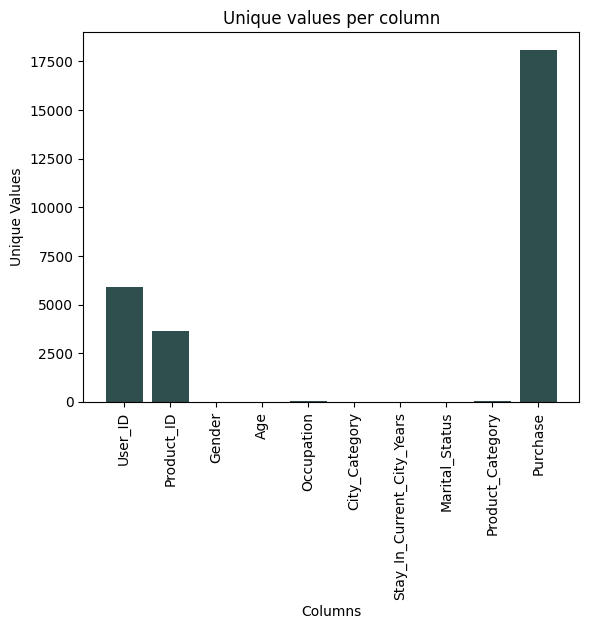

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category                 20
Purchase                      18105
dtype: int64


In [5]:
plt.bar(df.nunique().index,df.nunique(),color = 'darkslategray')
plt.xticks(rotation =90)
plt.xlabel('Columns')
plt.ylabel('Unique Values')
plt.title('Unique values per column' )
plt.show()
print(df.nunique())

# Feature Engineering

In [6]:
# Just changing numerical of marital status for better visualization
df['Marital_Status'] = df['Marital_Status'].apply(lambda x:'Unmarried' if x == 0 else 'Married' )

In [7]:
# changing datatypes of these columns to avoid aggregation.
df['User_ID']=df['User_ID'].astype('object')
df['Occupation']=df['Occupation'].astype('object')
df['Product_Category']=df['Product_Category'].astype('object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  object
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 42.0+ MB


# Missing values and duplicate rows.

In [9]:
df.isna().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [10]:
df.duplicated().sum()

np.int64(0)

# Statistical information.

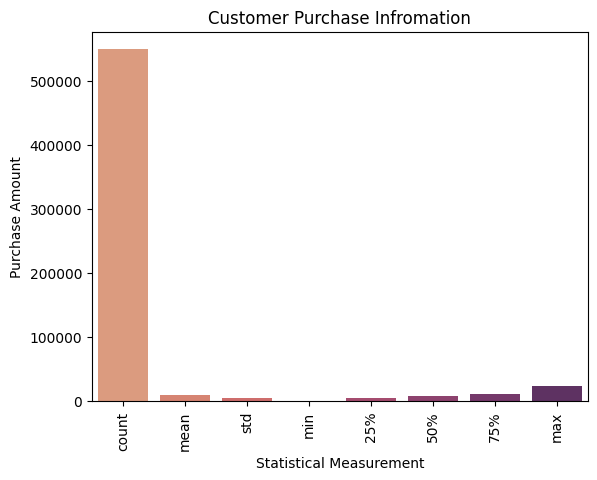

   index       Purchase
0  count  550068.000000
1   mean    9263.968713
2    std    5023.065394
3    min      12.000000
4    25%    5823.000000
5    50%    8047.000000
6    75%   12054.000000
7    max   23961.000000


In [11]:
stat_data = df.describe().reset_index()
sns.barplot(x = 'index',y = 'Purchase',data = stat_data,palette = 'flare')
plt.xticks(rotation = 90)
plt.xlabel('Statistical Measurement')
plt.ylabel('Purchase Amount')
plt.title('Customer Purchase Infromation')
plt.show()
print(stat_data)


In [12]:
df.describe(include='object').T

,count,unique,top,freq
User_ID,550068,5891,1001680,1026
Product_ID,550068,3631,P00265242,1880
Gender,550068,2,M,414259
Age,550068,7,26-35,219587
Occupation,550068,21,4,72308
City_Category,550068,3,B,231173
Stay_In_Current_City_Years,550068,5,1,193821
Marital_Status,550068,2,Unmarried,324731
Product_Category,550068,20,5,150933


# Detecting Outliers

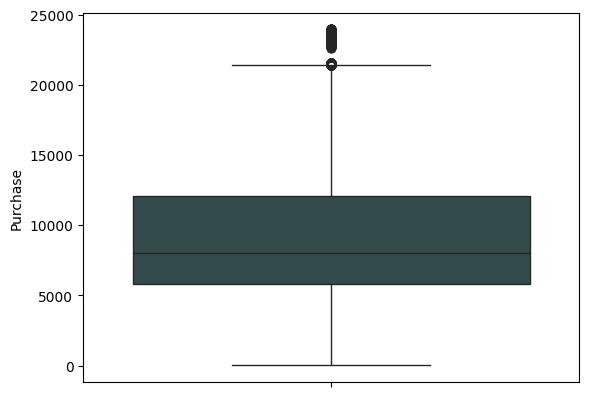

In [13]:
sns.boxplot(df['Purchase'], color  = 'darkslategray')
plt.show()

▶ No outliers on the lower end.




# Percentage of Outliers

In [14]:
iqr = np.percentile(df['Purchase'],75)-np.percentile(df['Purchase'],25)
upper_bound = int(np.percentile(df['Purchase'],75)+(1.5*iqr))
outliers_percentage= len(df[df['Purchase']> upper_bound]['Purchase'])/len(df['Purchase'])*100
print(f'Percentage of outliers: {outliers_percentage:.2f}')


Percentage of outliers: 0.49


▶ Since, the Percentage of outliers are less than 1%, it will not impact analysis. so, we don't need to drop them.

▶ furthermore, all the outliers are on the higher end, which indicates the purchase amount of high value customers.

# Gender based analysys





In [15]:
# number of customers
customer_per_gender =df.groupby('Gender')['User_ID'].nunique()
customer_per_gender

,User_ID
Gender,
F,1666
M,4225


In [16]:
# Total Transaction
total_transaction_per_gender = df.groupby('Gender')['Purchase'].sum()
total_transaction_per_gender

,Purchase
Gender,
F,1186232642
M,3909580100


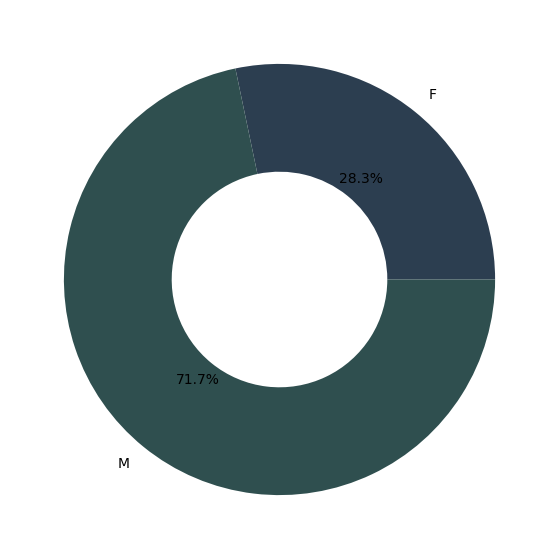

In [17]:
color = ['#2c3e50','darkslategray']
plt.figure(figsize = (10,7))
plt.pie(customer_per_gender,labels=customer_per_gender.index,autopct='%1.1f%%',wedgeprops={'width': 0.5}, colors = color)
plt.show()

▶ Significant difference between size of male and female customers and their total transaction.

# Gender purchasing pattern

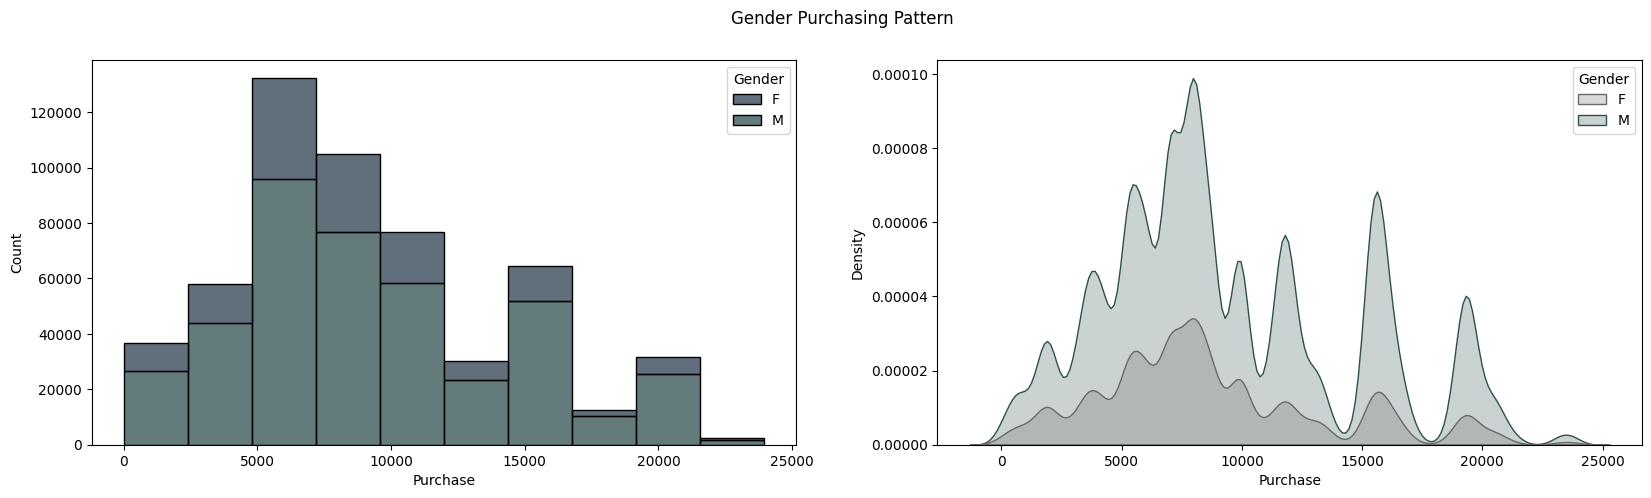

In [18]:
color2 = ['dimgray','darkslategray']
fig,ax = plt.subplots(1,2,figsize = (20,5))

sns.histplot(x='Purchase', data=df, hue ='Gender', multiple ='stack',bins=10 ,palette = color, ax = ax[0])

sns.kdeplot(x='Purchase', data=df, hue ='Gender',palette = color2,fill = True, ax = ax[1])
plt.suptitle('Gender Purchasing Pattern')
plt.show()

▶ Similar purchasing pattern for by both genders.

# Confidence Interval 1

In [19]:
male_data = df[df['Gender']== 'M']
female_data = df[df['Gender']== 'F']

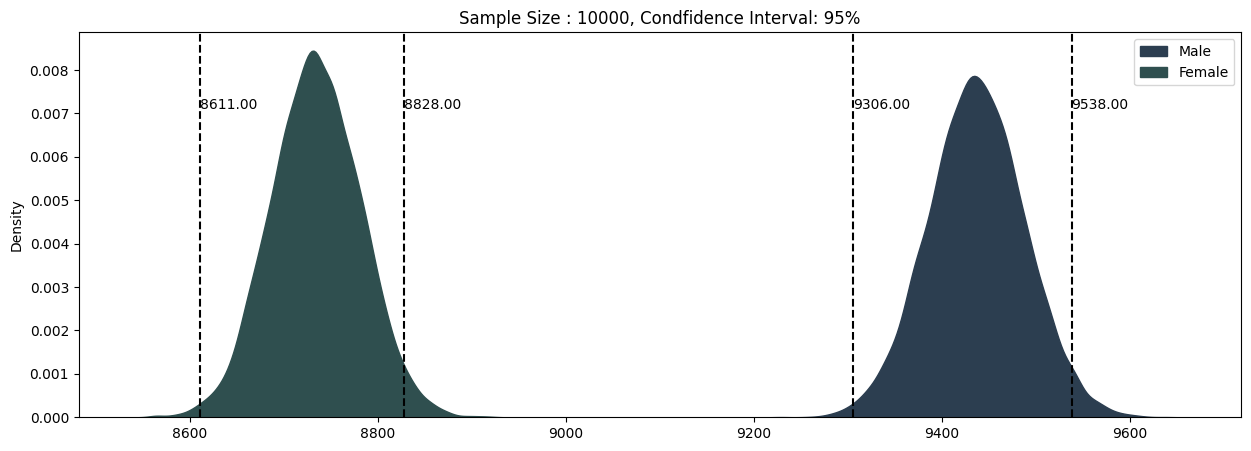

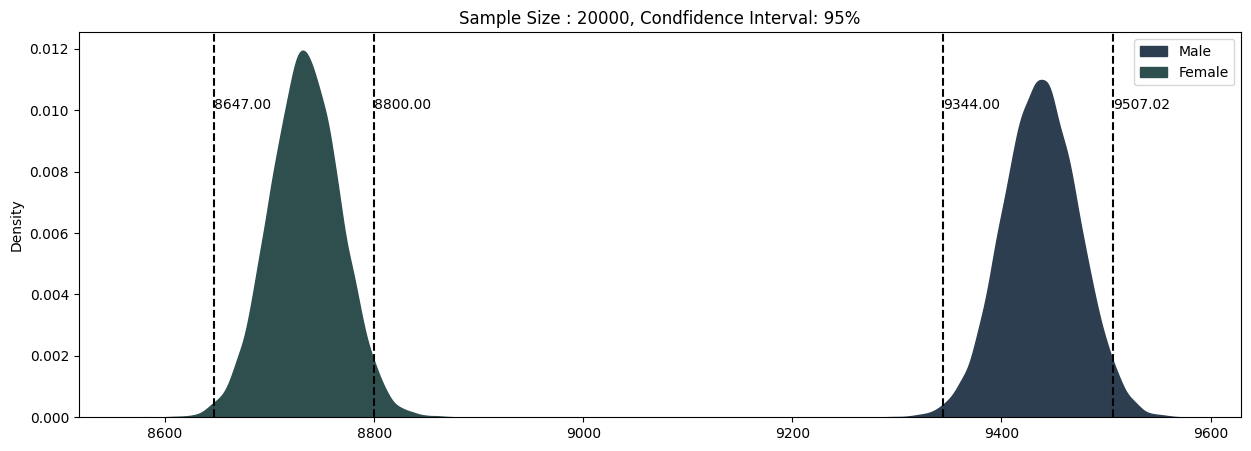

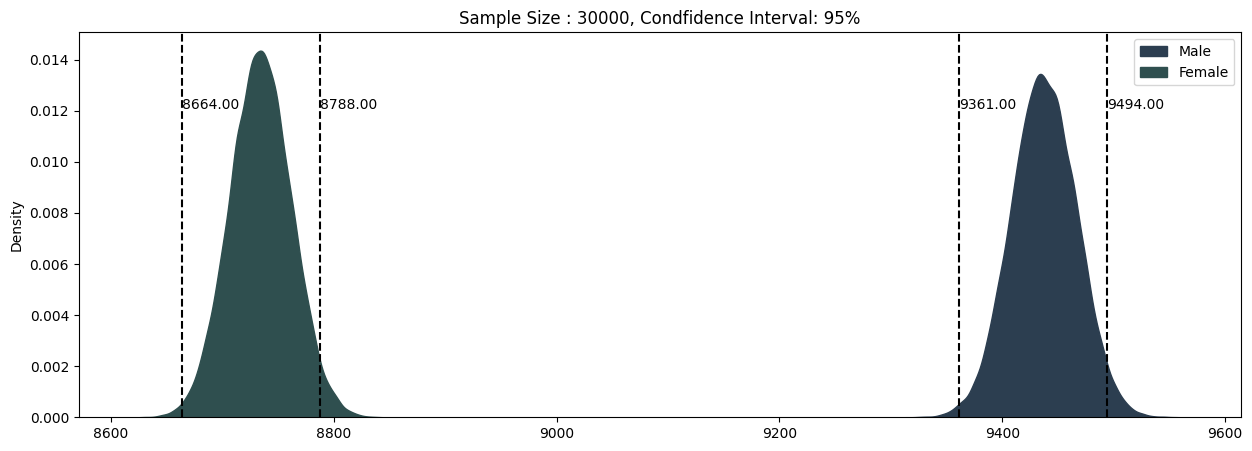

In [20]:
def ci_visualization(data1,data2,colors,labels,sample_size,ll,hl,ci,si):
  for sample in sample_size:
    #Appliyng central limit theorem
    np.random.seed(42)
    means1 = [int(data1['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means2 = [int(data2['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]

    #95% confidence interval
    low_limit1 = np.percentile(means1,ll)
    high_limit1 = np.percentile(means1,hl)
    low_limit2 = np.percentile(means2,ll)
    high_limit2 = np.percentile(means2,hl)

    interval = [low_limit1,high_limit1,low_limit2,high_limit2]

    plt.figure(figsize=(15,5))
    sns.kdeplot(means1,fill = True,color = colors[0],label = labels[0],alpha = 1)
    sns.kdeplot(means2,fill = True,color = colors[1],label = labels[1],alpha = 1)

    for _ in interval:
      plt.axvline(_,color = 'black',linestyle = '--')
      plt.text(_,plt.ylim()[1]*0.8,f'{_:.2f}')
    plt.legend()
    plt.title(f'Sample Size : {sample}, Condfidence Interval: {ci}%')
    plt.show()


sample_size = [10000,20000,30000]
l = ['Male','Female']
ci_visualization(male_data,female_data,color,l,sample_size,.5,97.5,95,.05)


▶ Confidence interval for male and female is not overlapping.

▶ initial intution from the graph is that they belongs to different mean distribution, with Male per transaction is greater.

# Hypothesis Testing 1

* Testing if Male per trasaction is greater than female.


In [21]:
# Function to test mean of 1 category is greater or lesser.
def hypothesis_testing(d1,d2,sample_size,null_h,alt_h,ci,si,label):
  for sample in sample_size:
    np.random.seed(42)
    sample1 = d1['Purchase'].sample(sample,replace = True)
    sample2 = d2['Purchase'].sample(sample,replace = True)

    test_stat,pvalue = ttest_ind(sample1,sample2,alternative = alt_h)
    if pvalue < si:
      print(f'sample Size: {sample}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} < {si} thus, we reject the null hypothesis.
Average Per Transaction of {label[0]} is {alt_h} than {label[1]}.

''')
    else:
      print(f'sample Size: {sample}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} > {si} thus, we failed to reject the null hypothesis.
Average per Transaction of {label[0]} is {null_h} than {label[1]}.

''')

hypothesis_testing(male_data,female_data,[10000,20000,30000],"Not greater","greater",95,.05,['Male','Female'])

sample Size: 10000, Confidence level: 95%
P-value5.78811527538752e-23 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.


sample Size: 20000, Confidence level: 95%
P-value6.259049924141354e-44 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.


sample Size: 30000, Confidence level: 95%
P-value6.845728475468294e-76 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.




▶ Since, Average per transaction and total transaction of male is greater than female. following quesion arises:

# Gender Related questions.

Q.1 What is reason behind revenue generation ? Participation or high average transaction.

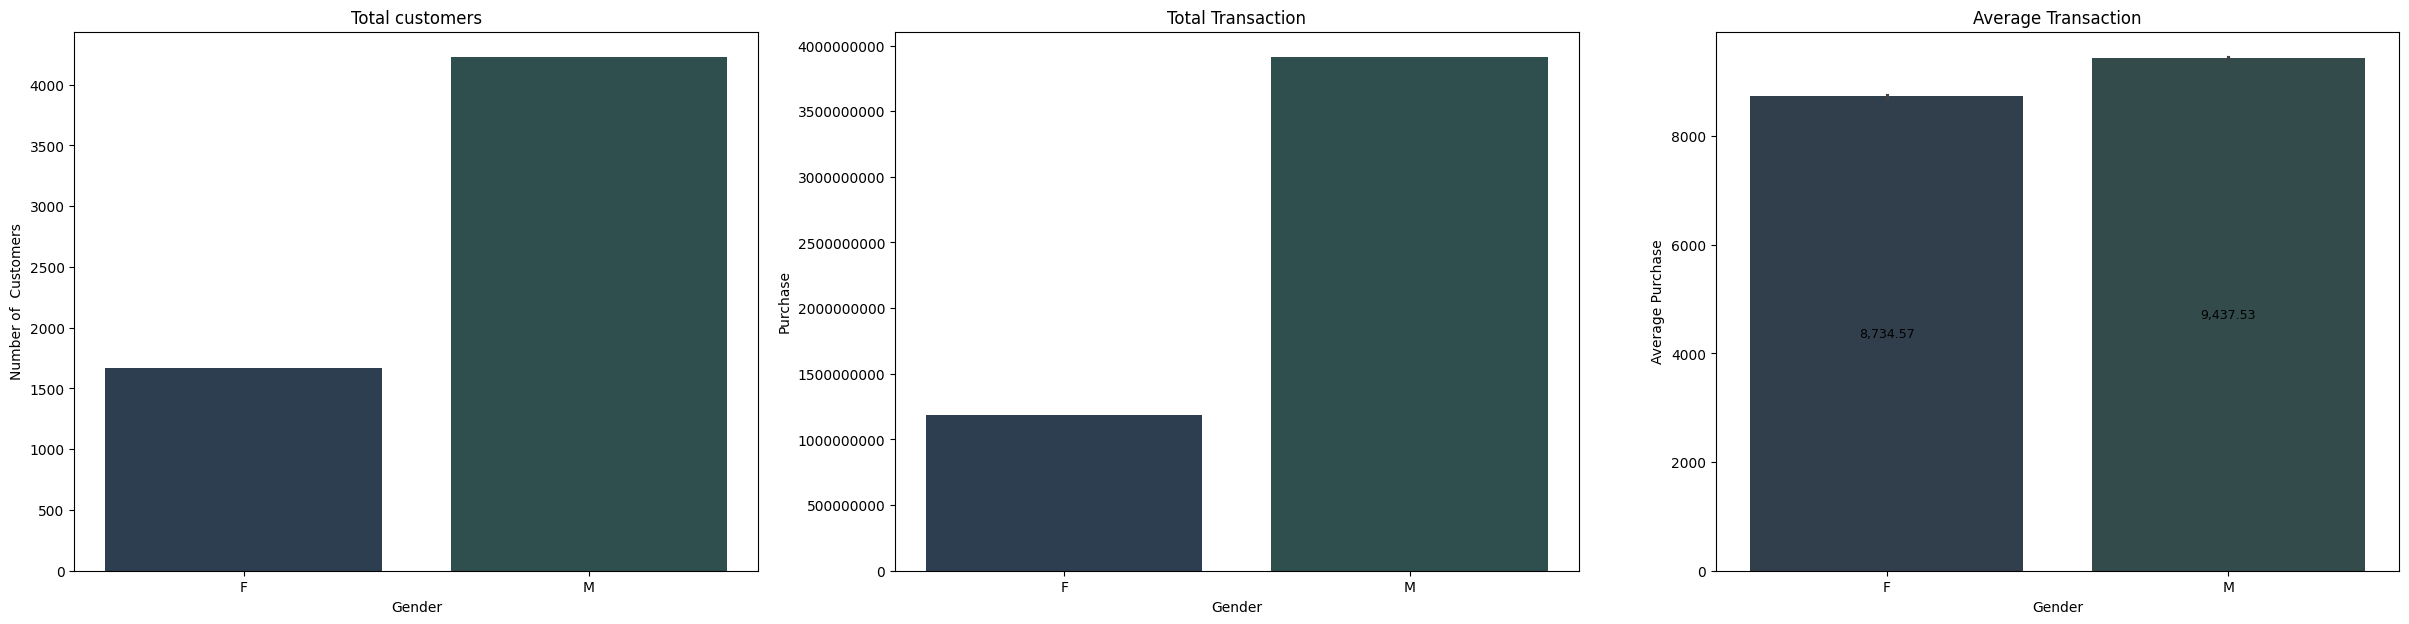

In [22]:
fig, ax = plt.subplots(1,3,figsize =(30,7))
ax[0].bar(customer_per_gender.index,customer_per_gender,color=color)
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Number of  Customers')
ax[0].set_title('Total customers')

ax[1].bar(total_transaction_per_gender.index,total_transaction_per_gender,color = color)
ax[1].set_xlabel('Gender')
ax[1].set_ylabel('Purchase')
ax[1].ticklabel_format(style='plain', axis='y')
ax[1].set_title('Total Transaction')


sns.barplot(x = 'Gender', y = 'Purchase', data = df, palette = color, ax = ax[2])
ax[2].set_xlabel('Gender')
ax[2].set_ylabel('Average Purchase')
ax[2].set_title('Average Transaction')
for container in ax[2].containers:
  ax[2].bar_label(container, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0)
plt.show()

plt.show()


▶ comparing above plots confirmed that, average per transaction has minimal impact on revenue generation while customer participation plays a crucial role.

Q.2 Around 70% revenue gererated by male customers compare to female with around 30%, does this difference make gender a defining factor in relation with other demographies like age,marital status, city etc.

In [23]:
def stack_func(data,col1,col2,col3,clr,row,column,size,val=None,rot = 0, rot2 = 0):

  if val is not None:

    agg1 = data.groupby([col1, col2])[col3].sum().unstack().sort_values(by =[val[0],val[1]], ascending =  False)
    agg2 = data.groupby([col1, col2])[col3].mean().unstack().sort_values(by =[val[0],val[1]], ascending =  False)
  else:

    agg1 = data.groupby([col1, col2])[col3].sum().unstack()
    agg2 = data.groupby([col1, col2])[col3].mean().unstack()

  fig,ax = plt.subplots(row,column, figsize = size)

  agg1.plot(kind='bar', stacked=True,color=clr, ax = ax[0])
  ax[0].ticklabel_format(style='plain', axis='y')
  ax[0].tick_params(axis = 'x', rotation = rot)
  ax[0].set_title('Total Transaction')


  agg2.plot(kind='bar', stacked=True,color=clr, ax = ax[1])
  ax[1].tick_params(axis = 'x', rotation = rot)
  ax[1].set_title('Average Transaction')
  ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  for container in ax[1].containers:
    ax[1].bar_label(container, fmt='{:,.0f}',label_type='center', fontsize=9,rotation=rot2)


  plt.show()

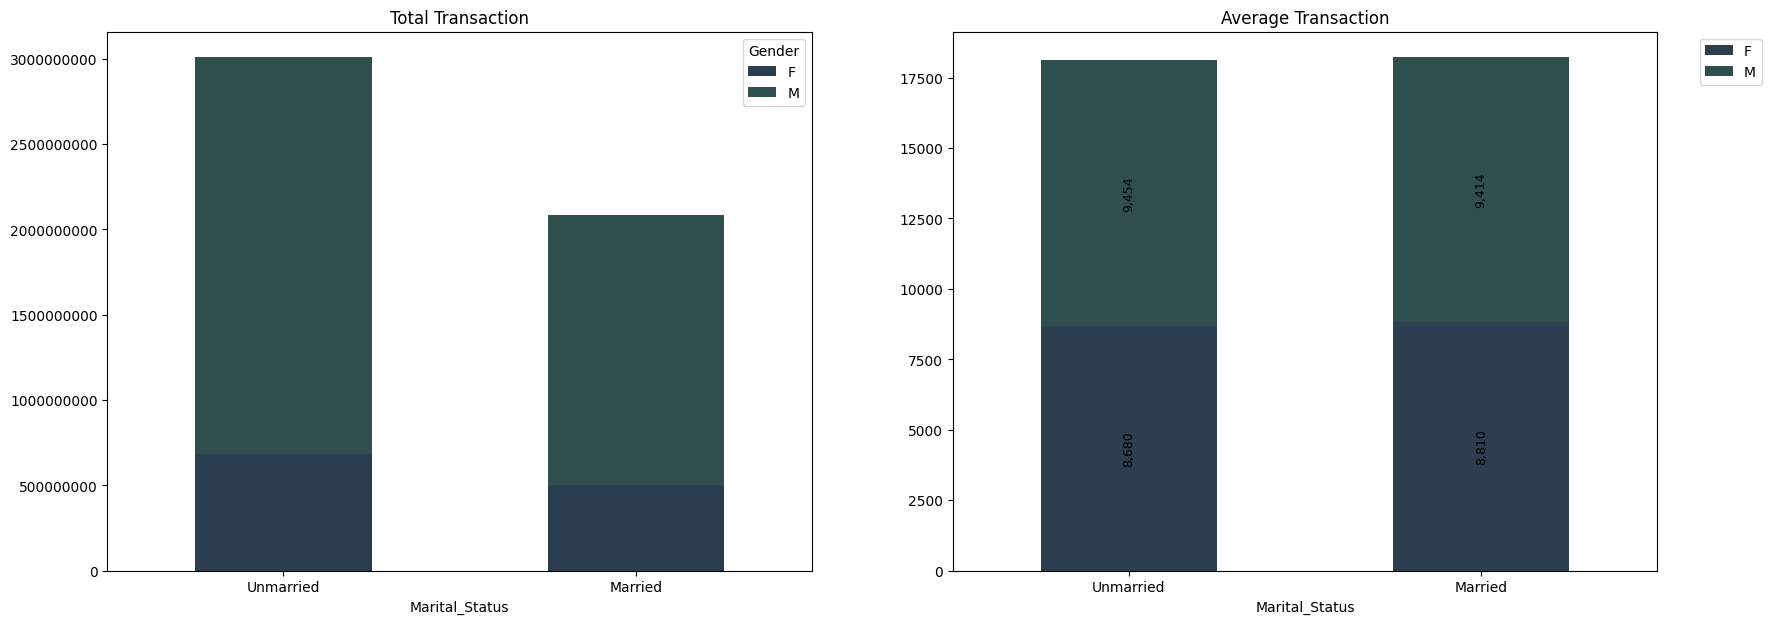

In [24]:
stack_func(df,'Marital_Status','Gender','Purchase',color,1,2,(20,7),['M','F'],0,90)

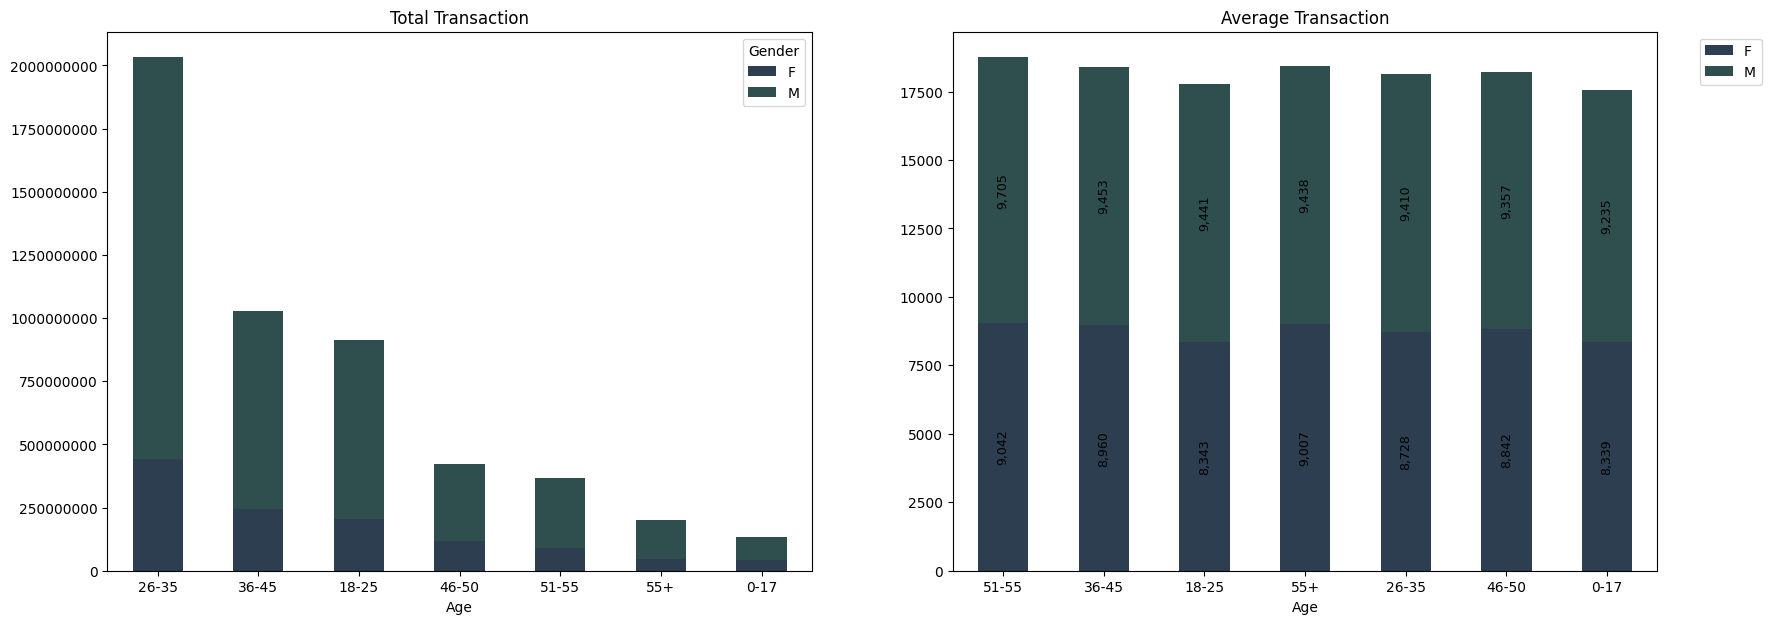

In [25]:
stack_func(df,'Age','Gender','Purchase',color,1,2,(20,7),['M','F'],0,90)

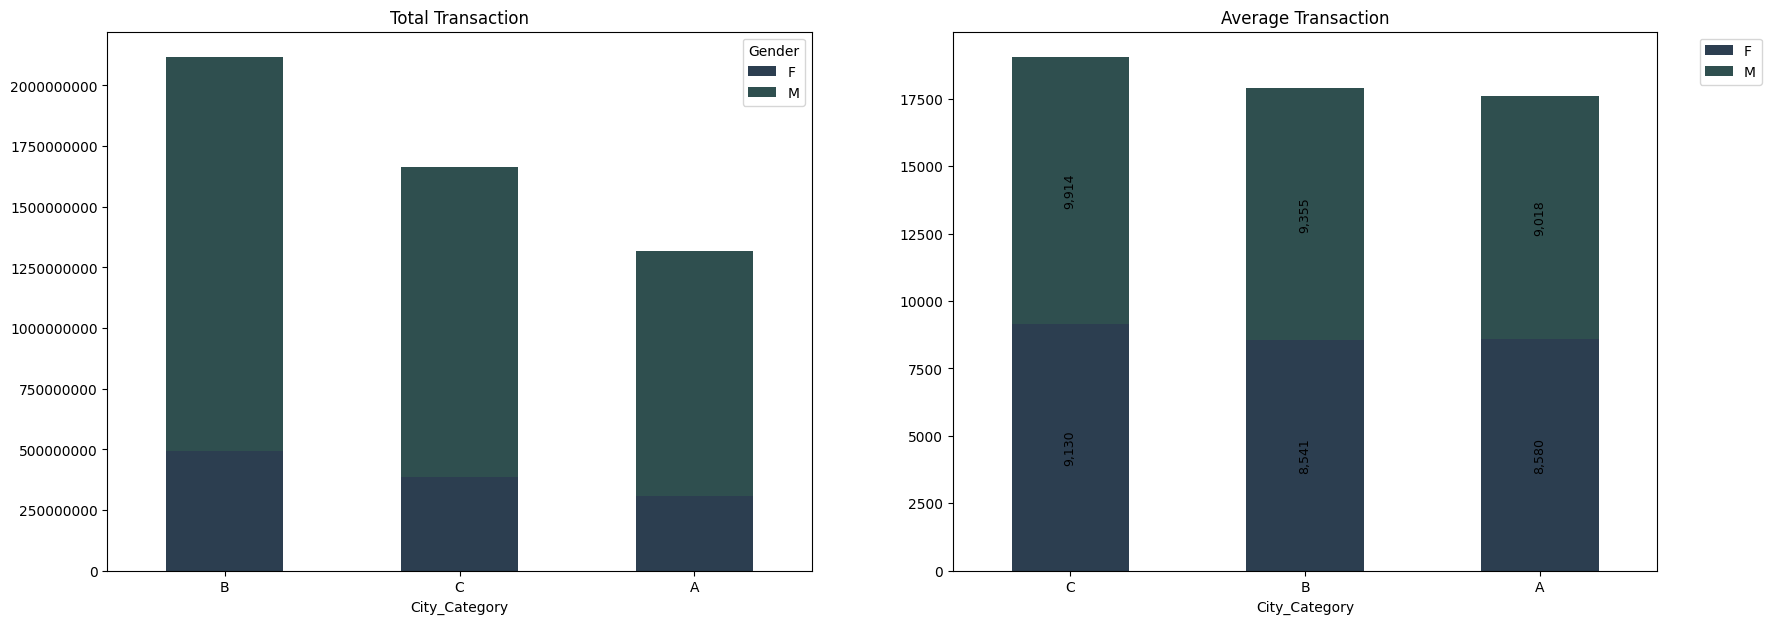

In [26]:
stack_func(df,'City_Category','Gender','Purchase',color,1,2,(20,7),['M','F'],0,90)

 ▶ Dominance of Gender is clearly visible in relation with other demographies. not just participation but in terms of average too.

 ▶ This suggests that gender is most insightful demography in decision making process.

# Martial Status Column Analysis



In [27]:
customer_per_MS =df.groupby('Marital_Status')['User_ID'].nunique()
customer_per_MS

,User_ID
Marital_Status,
Married,2474
Unmarried,3417


In [28]:
total_transaction_per_MS= df.groupby('Marital_Status')['Purchase'].sum()
total_transaction_per_MS

,Purchase
Marital_Status,
Married,2086885295
Unmarried,3008927447


# Purchasing Pattern based on Marital Status.

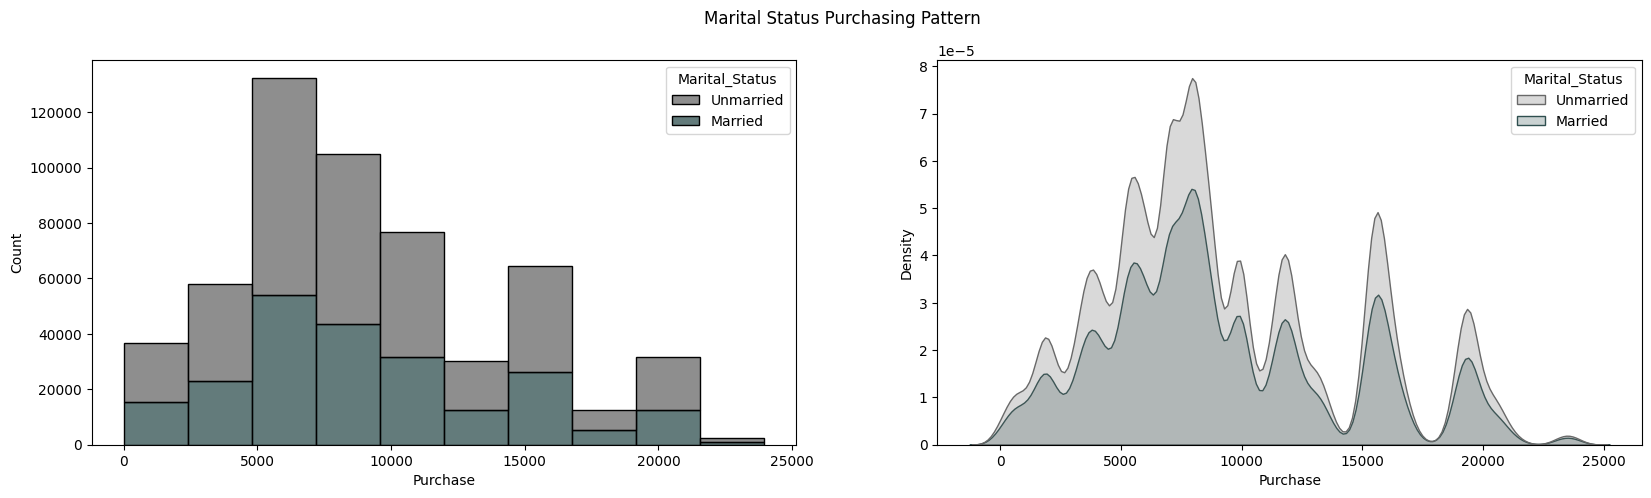

In [29]:
fig,ax = plt.subplots(1,2,figsize = (20,5))

sns.histplot(x='Purchase', data=df, hue ='Marital_Status', multiple ='stack',bins=10 ,palette = color2, ax = ax[0])

sns.kdeplot(x='Purchase', data=df, hue ='Marital_Status',palette = color2,fill = True, ax = ax[1])
plt.suptitle('Marital Status Purchasing Pattern')
plt.show()

▶ similar purchasing pattern followed with slight difference in density.


In [30]:
married_data = df[df['Marital_Status'] == 'Married']
unmarried_data = df[df['Marital_Status'] == 'Unmarried']

# confidence interval 2

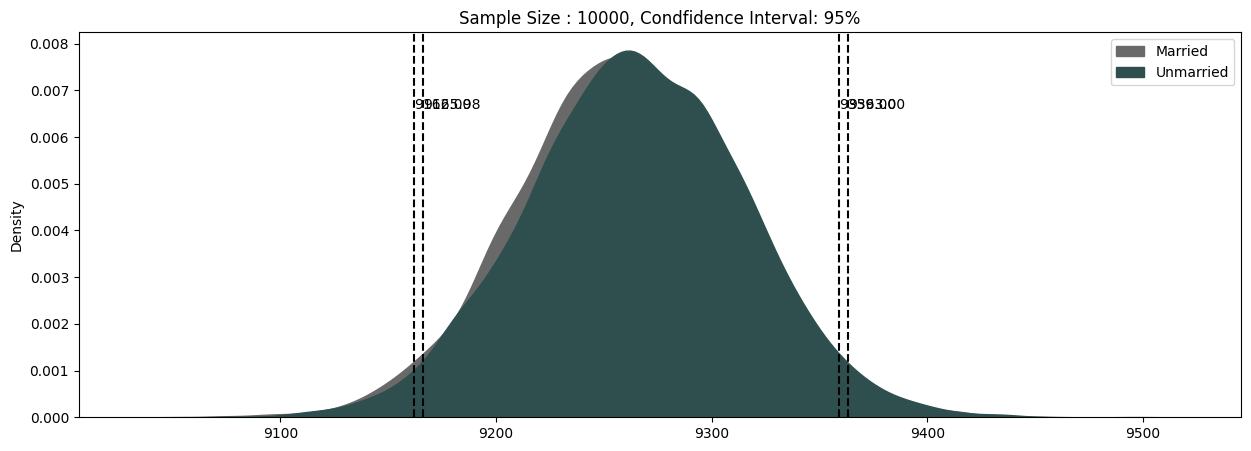

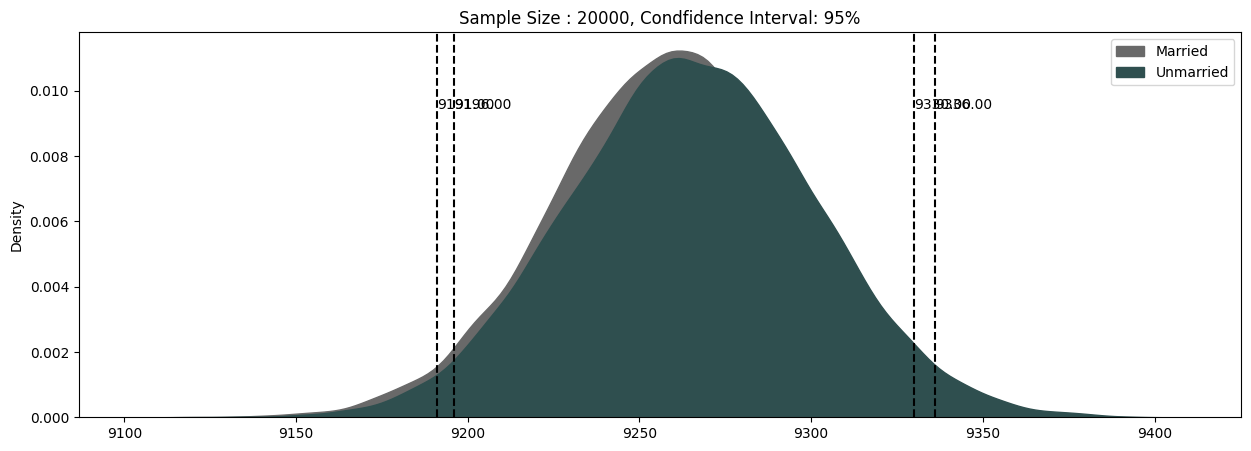

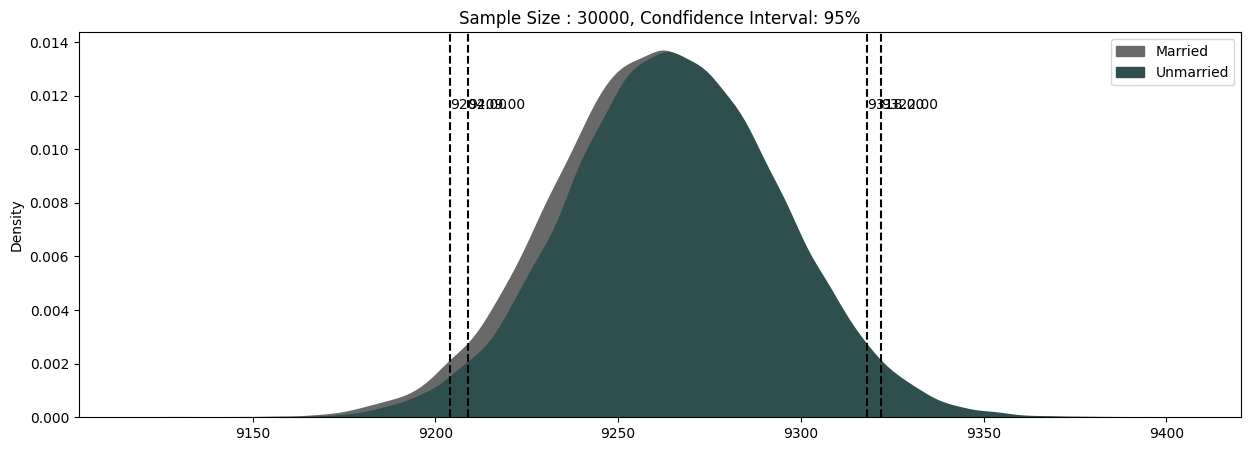

In [32]:
sample_size = [10000,20000,30000]
c = ['olive','teal']
l2 = ['Married','Unmarried']
ci_visualization(married_data,unmarried_data,color2,l2,sample_size,2.5,97.5,95,.05)

▶ Confidence interval is overlapping.

▶ However, with the increase in sample size overlapping decreases, still there is no clear difference.


# Hypothesis testing 2


In [33]:
# Function to test mean of a category is different from other or not.
def hypothesis_testing2(d1,d2,sample_size,ci,si,label):
  for sample in sample_size:
    np.random.seed(42)
    sample1 = d1['Purchase'].sample(sample,replace = True)
    sample2 = d2['Purchase'].sample(sample,replace = True)

    test_stat,pvalue = ttest_ind(sample1,sample2)
    if pvalue < si:
      print(f'sample Size: {sample}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} < {si} thus, we reject the null hypothesis.
Average per Transaction amount of {label[0]} is different from {label[1]}.

''')
    else:
      print(f'sample Size: {sample}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} > {si} thus, we failed to reject the null hypothesis.
Average per Transaction of {label[0]} is not different from {label[1]}.

''')

hypothesis_testing2(unmarried_data,married_data,[10000,20000,30000],95,.05,['unmarried','married'])

sample Size: 10000, Confidence level: 95%
P-value0.5216435839959059 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of unmarried is not different from married.


sample Size: 20000, Confidence level: 95%
P-value0.8085149284222338 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of unmarried is not different from married.


sample Size: 30000, Confidence level: 95%
P-value0.7648837554630464 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of unmarried is not different from married.




# Marital Status related questions.



Q.1 Since, there is no difference in average per transaction,number of customers seems to the main reason behind revenue generation. visualize it.

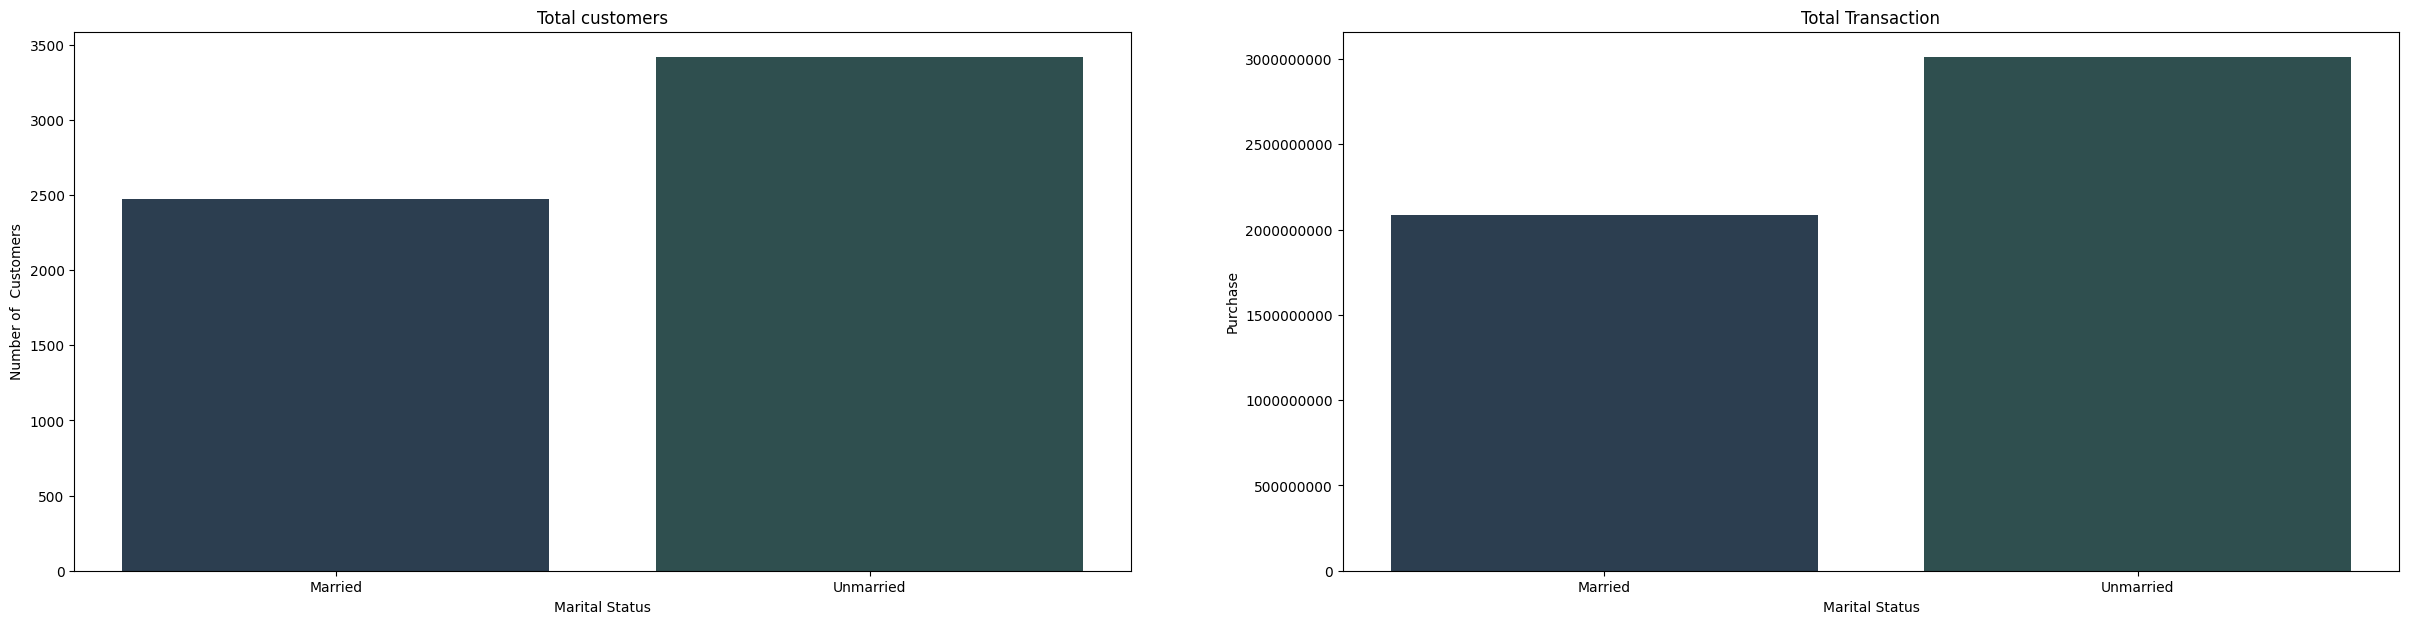

In [34]:
fig, ax = plt.subplots(1,2,figsize =(30,7))
ax[0].bar(customer_per_MS.index,customer_per_MS,color=color)
ax[0].set_xlabel('Marital Status')
ax[0].set_ylabel('Number of  Customers')
ax[0].set_title('Total customers')

ax[1].bar(total_transaction_per_MS.index,total_transaction_per_MS,color = color)
ax[1].set_xlabel('Marital Status')
ax[1].set_ylabel('Purchase')
ax[1].ticklabel_format(style='plain', axis='y')
ax[1].set_title('Total Transaction')
plt.show()

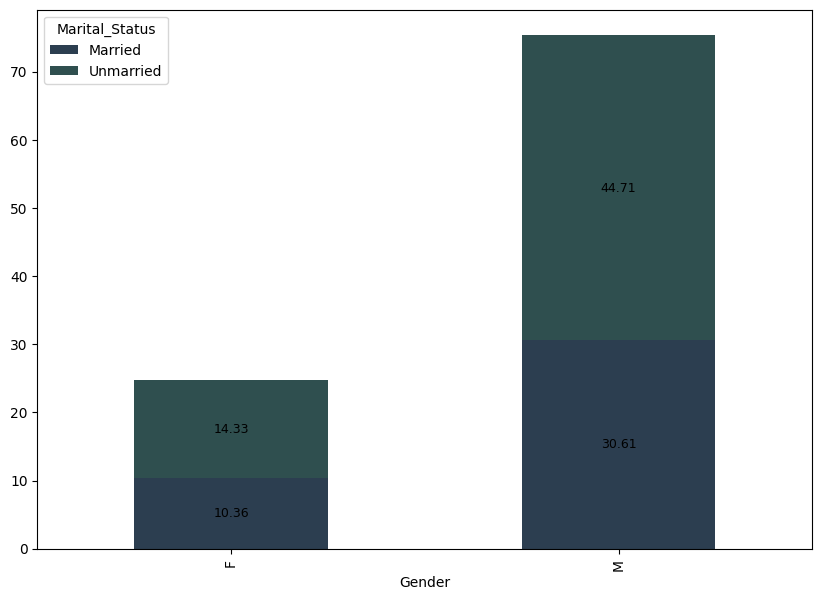

In [35]:
dta = pd.crosstab(df['Gender'],df['Marital_Status'], normalize = True)*100
fig, ax = plt.subplots(1,1,figsize = (10,7))
dta.plot(kind = 'bar', stacked = True,color = color, ax = ax)
for i in ax.containers:
    ax.bar_label(i, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0)
plt.show()

▶ A big share of revenue generated by transaction made by unmarried customers.

▶ The reason behind revenue is participation. however due to percentage of unmarried male customer(44%) compare to married male(30%) is less,there might a slight difference in average per transaction in favour of unmarried which isn't even captured by hypothesis testing.

# Age based analysis


In [36]:
customer_per_age_group = df.groupby('Age')['User_ID'].nunique()
customer_per_age_group

,User_ID
Age,
0-17,218
18-25,1069
26-35,2053
36-45,1167
46-50,531
51-55,481
55+,372


In [37]:
total_transaction_per_age_group = df.groupby('Age')['Purchase'].sum()
total_transaction_per_age_group

,Purchase
Age,
0-17,134913183
18-25,913848675
26-35,2031770578
36-45,1026569884
46-50,420843403
51-55,367099644
55+,200767375


# Purchasing Pattern(Age)

In [38]:
age_0_17 = df[df['Age'] == '0-17']
age_18_25 = df[df['Age'] == '18-25']
age_26_35 = df[df['Age'] == '26-35']
age_36_45 = df[df['Age'] == '36-45']
age_46_50 = df[df['Age'] == '46-50']
age_51_55 = df[df['Age'] == '51-55']
age_55_plus = df[df['Age'] == '55+']

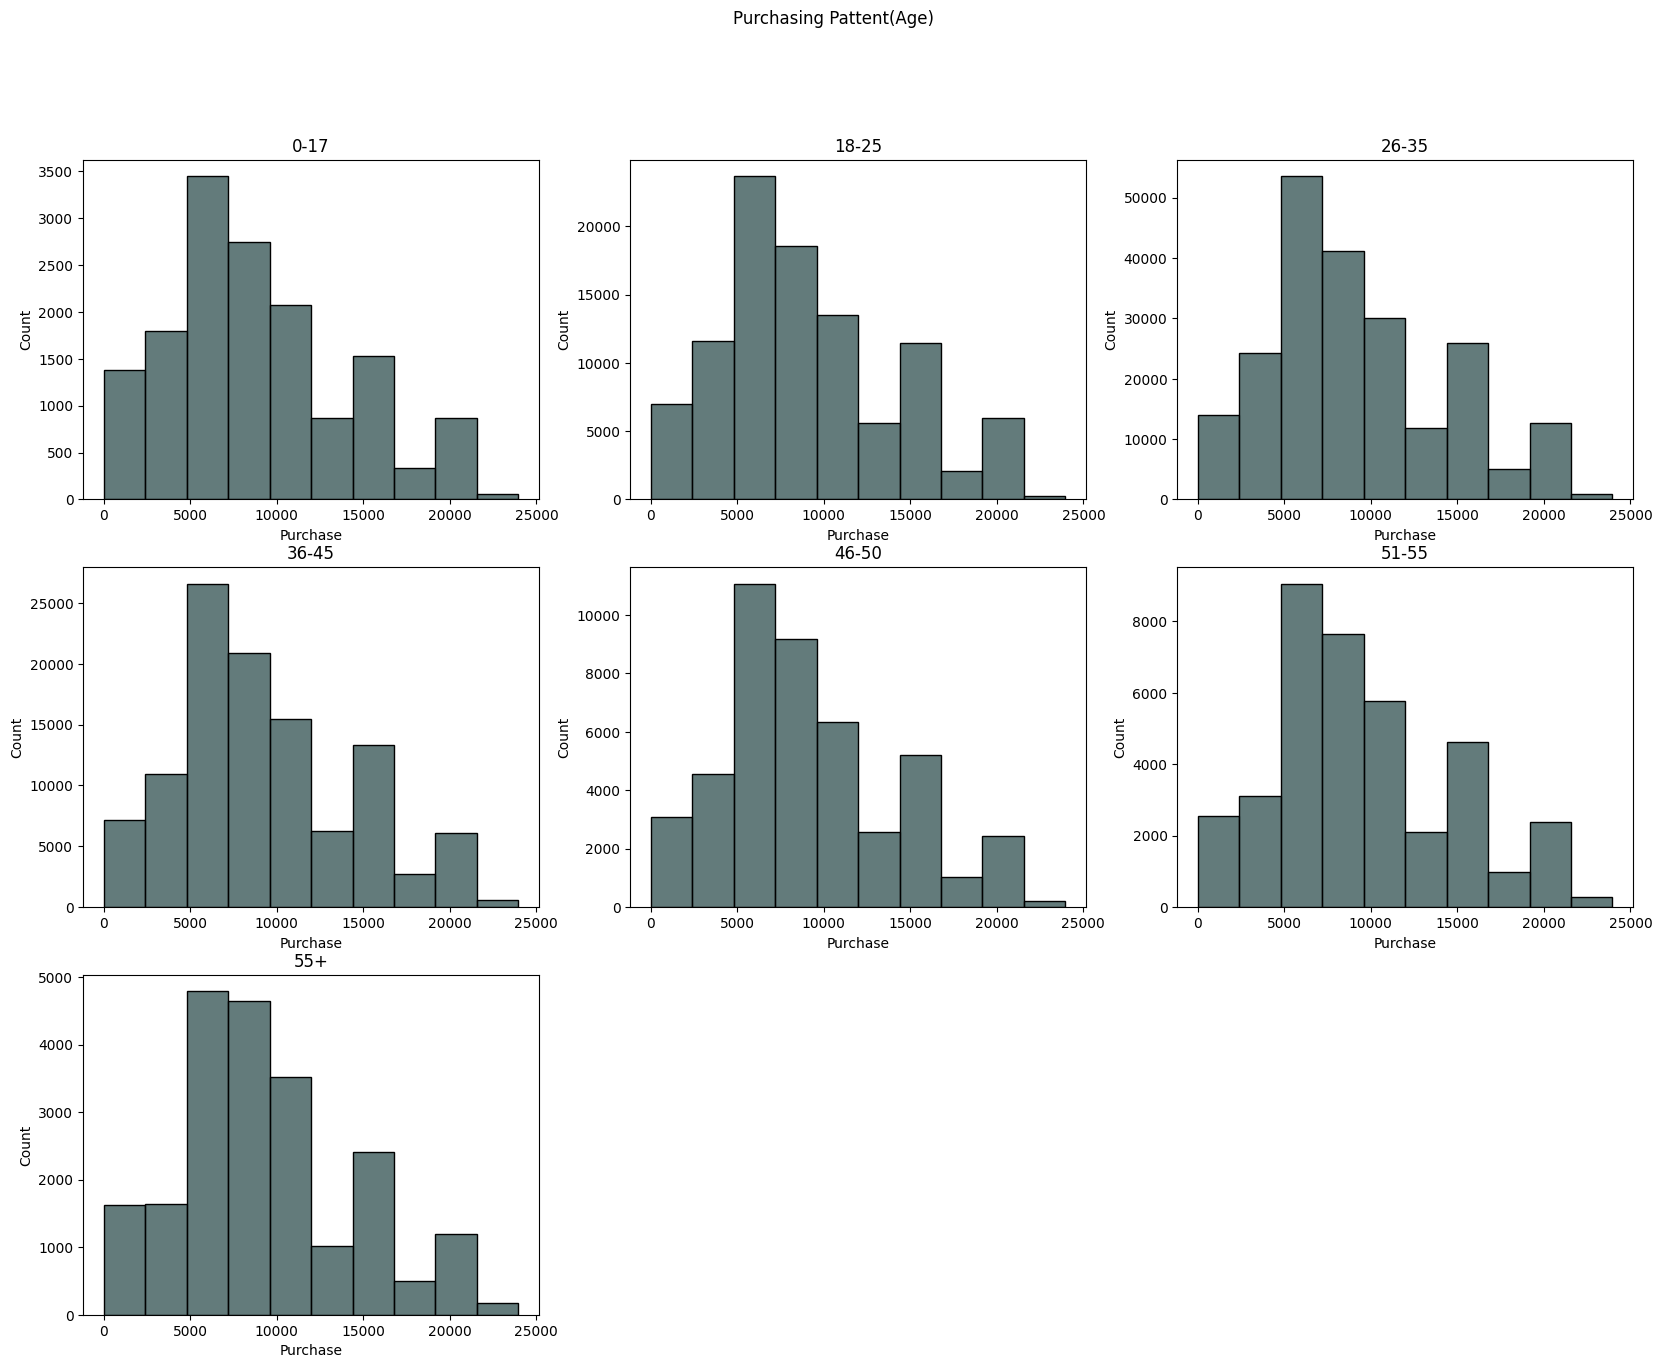

In [39]:
fig = plt.figure(figsize = (20,15))
plt.subplot(3,3,1)
sns.histplot(x = 'Purchase', data = age_0_17,bins = 10, color = 'darkslategray')
plt.title('0-17')

plt.subplot(3,3,2)
sns.histplot(x = 'Purchase', data = age_18_25,bins = 10, color = 'darkslategray')
plt.title('18-25')

plt.subplot(3,3,3)
sns.histplot(x = 'Purchase', data = age_26_35,bins = 10, color = 'darkslategray')
plt.title('26-35')

plt.subplot(3,3,4)
sns.histplot(x = 'Purchase', data = age_36_45,bins = 10, color = 'darkslategray')
plt.title('36-45')

plt.subplot(3,3,5)
sns.histplot(x = 'Purchase', data = age_46_50,bins = 10, color = 'darkslategray')
plt.title('46-50')

plt.subplot(3,3,6)
sns.histplot(x = 'Purchase', data = age_51_55,bins = 10, color = 'darkslategray')
plt.title('51-55')

plt.subplot(3,3,7)
sns.histplot(x = 'Purchase', data = age_55_plus,bins = 10, color = 'darkslategray')
plt.title('55+')

plt.suptitle('Purchasing Pattent(Age)')
plt.show()
plt.close()

▶ Similar prchasing pattern for all the age groups.

# Confidence interval 3

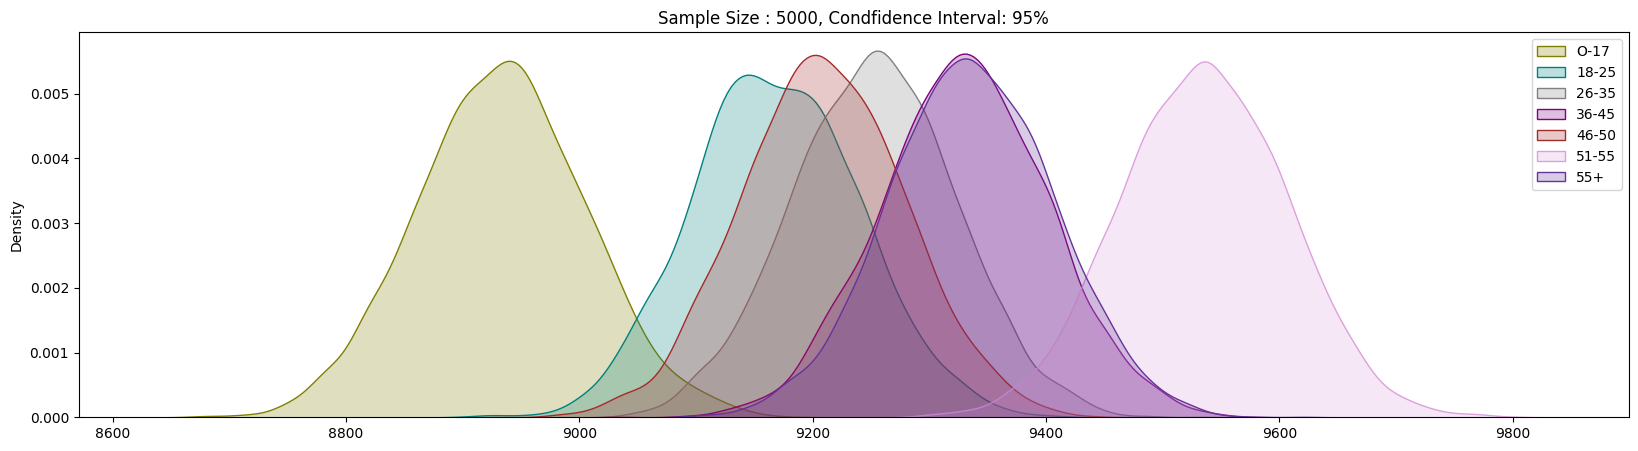

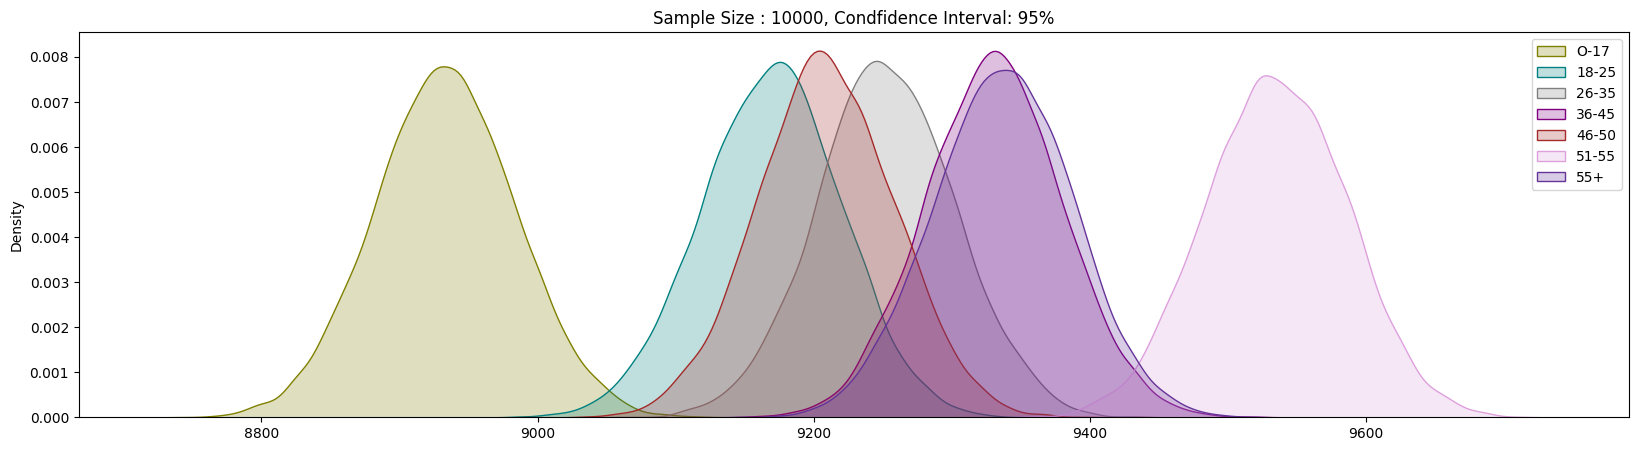

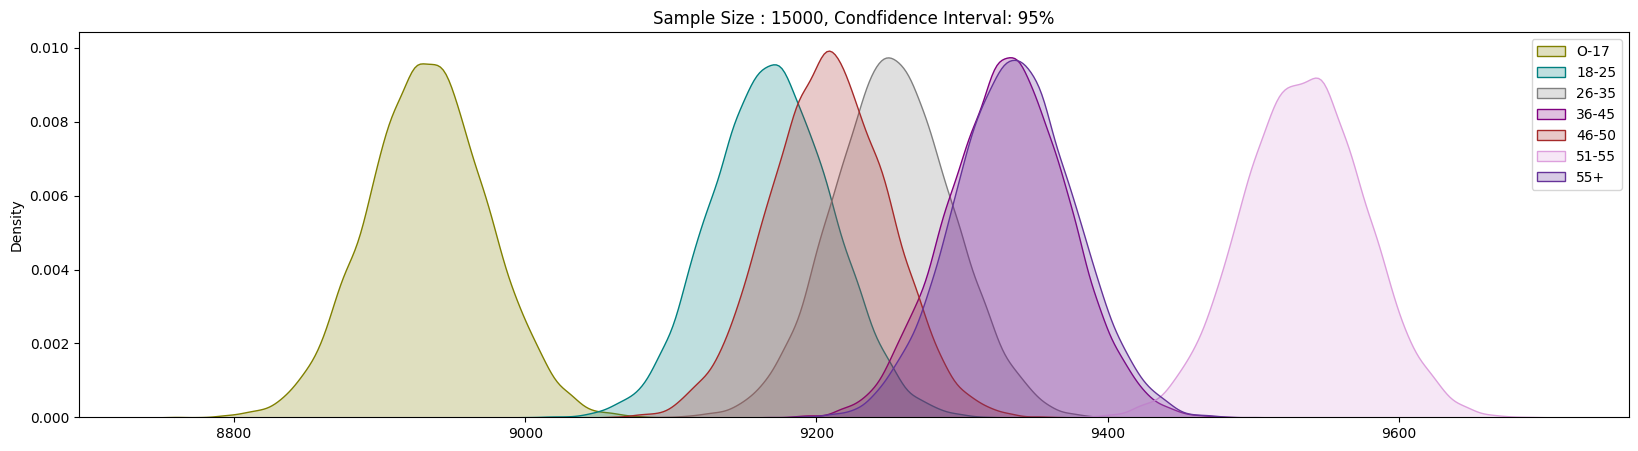

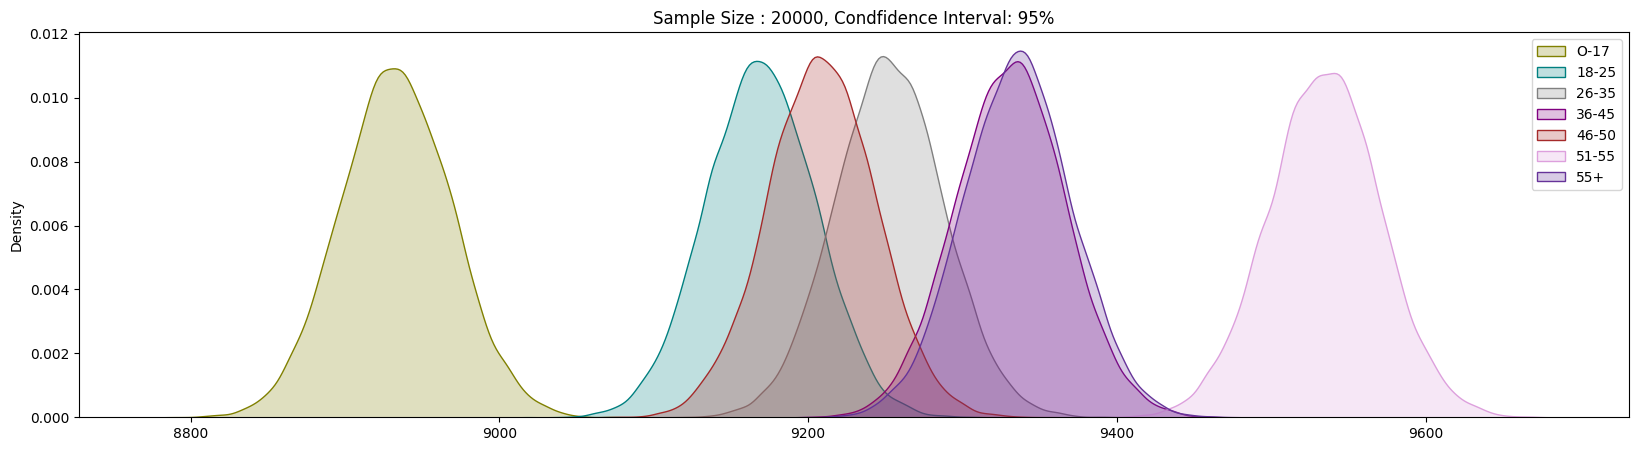

In [40]:
def ci_visualization2(data1,data2,data3,data4,data5,data6,data7,colors,labels,sample_size,ll,hl,ci,si):
  for sample in sample_size:
    #Appliyng central limit theorem
    np.random.seed(42)
    means1 = [int(data1['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means2 = [int(data2['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means3 = [int(data3['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means4 = [int(data4['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means5 = [int(data5['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means6 = [int(data6['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]
    means7 = [int(data7['Purchase'].sample(sample,replace = True).mean()) for i in range(sample)]

    #95% confidence interval
    low_limit1 = np.percentile(means1,ll)
    high_limit1 = np.percentile(means1,hl)
    low_limit2 = np.percentile(means2,ll)
    high_limit2 = np.percentile(means2,hl)
    low_limit3 = np.percentile(means3,ll)
    high_limit3 = np.percentile(means3,hl)
    low_limit4 = np.percentile(means4,ll)
    high_limit4 = np.percentile(means4,hl)
    low_limit5 = np.percentile(means5,ll)
    high_limit5 = np.percentile(means5,hl)
    low_limit6 = np.percentile(means6,ll)
    high_limit6 = np.percentile(means6,hl)
    low_limit7 = np.percentile(means7,ll)
    high_limit7 = np.percentile(means7,hl)


    interval = [low_limit1,high_limit1,low_limit2,high_limit2,low_limit3,high_limit3,low_limit4,high_limit4,
                low_limit5,high_limit5,low_limit6,high_limit6,low_limit7,high_limit7]

    plt.figure(figsize = (20,5))
    sns.kdeplot(means1,fill = True,color = colors[0],label = labels[0])
    sns.kdeplot(means2,fill = True,color = colors[1],label = labels[1])
    sns.kdeplot(means3,fill = True,color = colors[2],label = labels[2])
    sns.kdeplot(means4,fill = True,color = colors[3],label = labels[3])
    sns.kdeplot(means5,fill = True,color = colors[4],label = labels[4])
    sns.kdeplot(means6,fill = True,color = colors[5],label = labels[5])
    sns.kdeplot(means7,fill = True,color = colors[6],label = labels[6])


    plt.legend()
    plt.title(f'Sample Size : {sample}, Condfidence Interval: {ci}%')
    plt.show()
    plt.close()



sample_size = [5000,10000,15000,20000]
c = ['olive','teal','grey','purple','brown','plum','rebeccapurple']
l = ['O-17','18-25','26-35','36-45','46-50','51-55','55+']
ci_visualization2(age_0_17,age_18_25,age_26_35,age_36_45,age_46_50,age_51_55,age_55_plus,c,l,sample_size,2.5,97.5,95,.05)

▶ mean distribution each age group is overlapping with each other, except under-17 and 51-55, as they are far from each other.


# Hypothesis Testing 3

In [41]:
# function for anova test
def hypothesis_testing3(d1,d2,d3,d4,d5,d6,d7,sample_size,ci,si,label):
  for sample in sample_size:
    np.random.seed(42)
    sample1 = d1['Purchase'].sample(sample,replace = True)
    sample2 = d2['Purchase'].sample(sample,replace = True)
    sample3 = d3['Purchase'].sample(sample,replace = True)
    sample4 = d4['Purchase'].sample(sample,replace = True)
    sample5 = d5['Purchase'].sample(sample,replace = True)
    sample6 = d6['Purchase'].sample(sample,replace = True)
    sample7 = d7['Purchase'].sample(sample,replace = True)

    test_stat,pvalue = f_oneway(sample1,sample2,sample3,sample4,sample5,sample6,sample7)
    if pvalue < si:
      print(f'Sample size:{sample}')
      print(f'''P-value{pvalue} < {si}. thus, we reject the null hypothesis.
Average Purchase amount for different age group custromers are different from each other.''')
      print('    ')
    else:
      print(f'Sample size:{sample}')
      print(f'''P-value{pvalue} > {si}. thus, we failed to reject the null hypothesis.
Average Purchase amount for  different age group custromers are same.''')
      print('    ')


hypothesis_testing3(age_0_17,age_18_25,age_26_35,age_36_45,age_46_50,age_51_55,age_55_plus,[5000,10000,20000],95,.05,['unmarried','married'])

Sample size:5000
P-value2.6463113787230442e-06 < 0.05. thus, we reject the null hypothesis.
Average Purchase amount for different age group custromers are different from each other.
    
Sample size:10000
P-value3.8383339101189895e-10 < 0.05. thus, we reject the null hypothesis.
Average Purchase amount for different age group custromers are different from each other.
    
Sample size:20000
P-value1.7532546628991236e-27 < 0.05. thus, we reject the null hypothesis.
Average Purchase amount for different age group custromers are different from each other.
    


▶ Test suggests difference average per transaction between age groups,however only clear visible difference is between 0-17 and 51-55.

# Hypothesis testing 4

In [42]:
# testing either mean of 0-17 is lesser than its nearest mean distribution 18-25 or not.
hypothesis_testing(age_0_17,age_18_25,[5000,10000,20000],"Not less","less",95,.05,['0-17','18-25'])

sample Size: 5000, Confidence level: 95%
P-value0.08413540274208185 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of 0-17 is Not less than 18-25.


sample Size: 10000, Confidence level: 95%
P-value0.00915540689293582 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of 0-17 is less than 18-25.


sample Size: 20000, Confidence level: 95%
P-value9.466845959631157e-05 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of 0-17 is less than 18-25.




▶ With increase we can see the difference. since, average per transaction of age group is lesser than its nearest mean distribution 18-25,it is lesser than every other group.

# Hypothesis Testing 5

In [43]:
# testing either mean of 51-55 is greater than its nearest mean distribution 55+ or not.
hypothesis_testing(age_51_55,age_55_plus,[5000,10000,20000],"Not greater","greater",95,.05,['Male','Female'])

sample Size: 5000, Confidence level: 95%
P-value0.0021477586402758255 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.


sample Size: 10000, Confidence level: 95%
P-value0.025113697379482117 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.


sample Size: 20000, Confidence level: 95%
P-value0.00030716782418825476 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of Male is greater than Female.




▶ since, Average per transaction of age group 51-55 is greter than its nearest mean distribution 55+, it is greater than every other group.

# Age related question.

Q 1. What generates revenue.

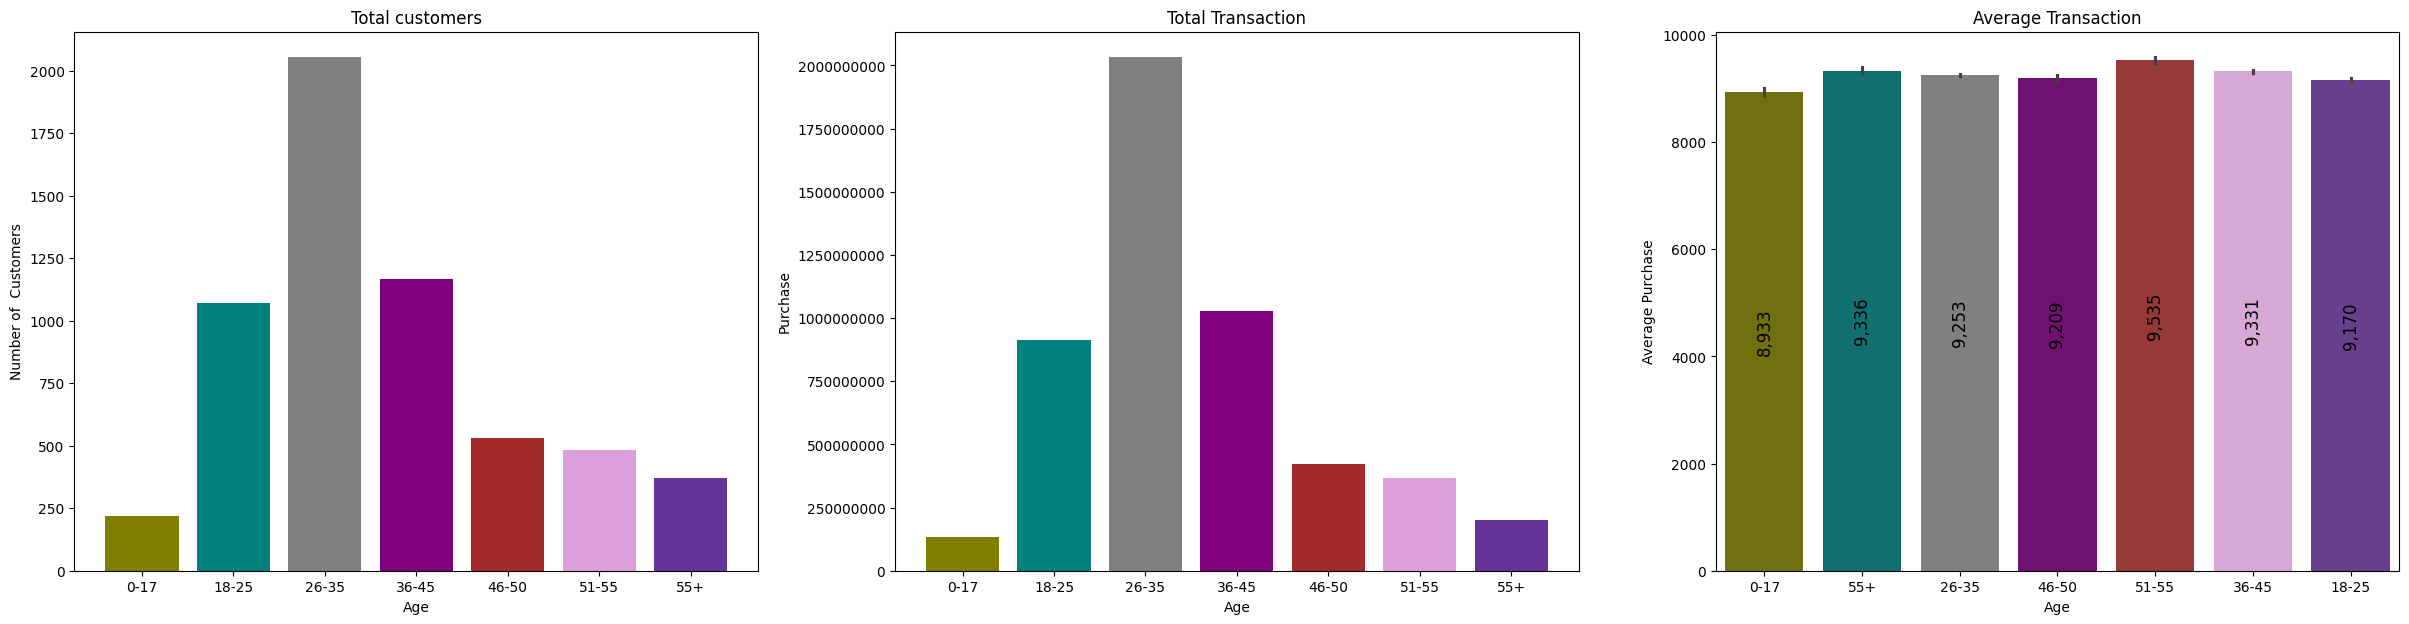

In [44]:
fig, ax = plt.subplots(1,3,figsize =(30,7))
ax[0].bar(customer_per_age_group.index,customer_per_age_group,color=c)
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Number of  Customers')
ax[0].set_title('Total customers')

ax[1].bar(total_transaction_per_age_group.index,total_transaction_per_age_group,color = c)
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Purchase')
ax[1].ticklabel_format(style='plain', axis='y')
ax[1].set_title('Total Transaction')


sns.barplot(x = 'Age', y = 'Purchase', data = df, palette = c, ax = ax[2])
ax[2].set_xlabel('Age')
ax[2].set_ylabel('Average Purchase')
ax[2].set_title('Average Transaction')
for container in ax[2].containers:
  ax[2].bar_label(container, fmt='{:,.0f}',label_type='center', fontsize=12,rotation=90)


plt.show()

▶ Analysis if multiple demographicies suggests that class with majority of customers is most likely to have highest contibution in total revenue.

Q.2 check the percentage of male and female customer in each age group to see, does the influence of gender on age group's average per transaction or not.

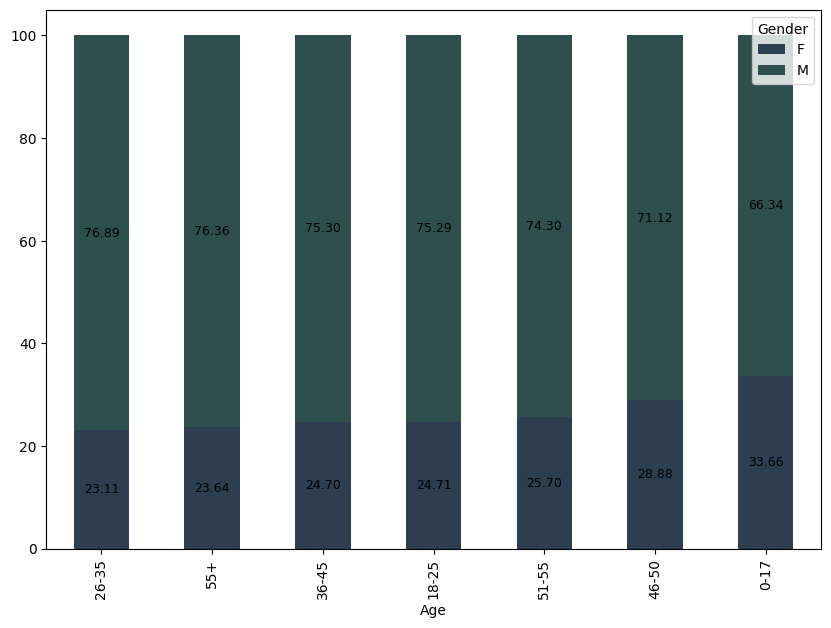

In [45]:
agg = pd.crosstab(df['Age'],df['Gender'],normalize = 'index').sort_values(by=['M','F'],ascending = False)*100
fig, ax = plt.subplots(1,1,figsize = (10,7))
agg.plot(kind = 'bar',stacked = True,color = color, ax =ax)
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0)
plt.show()


▶ only age group impacted by lack of male customers is 0-17,with lowest average per transaction.

▶ Average per transaction of other groups are not affected by gender,as they identical percentage of male and female customers.

▶ This makes age an important column in comparision with marital status.

# City category column.

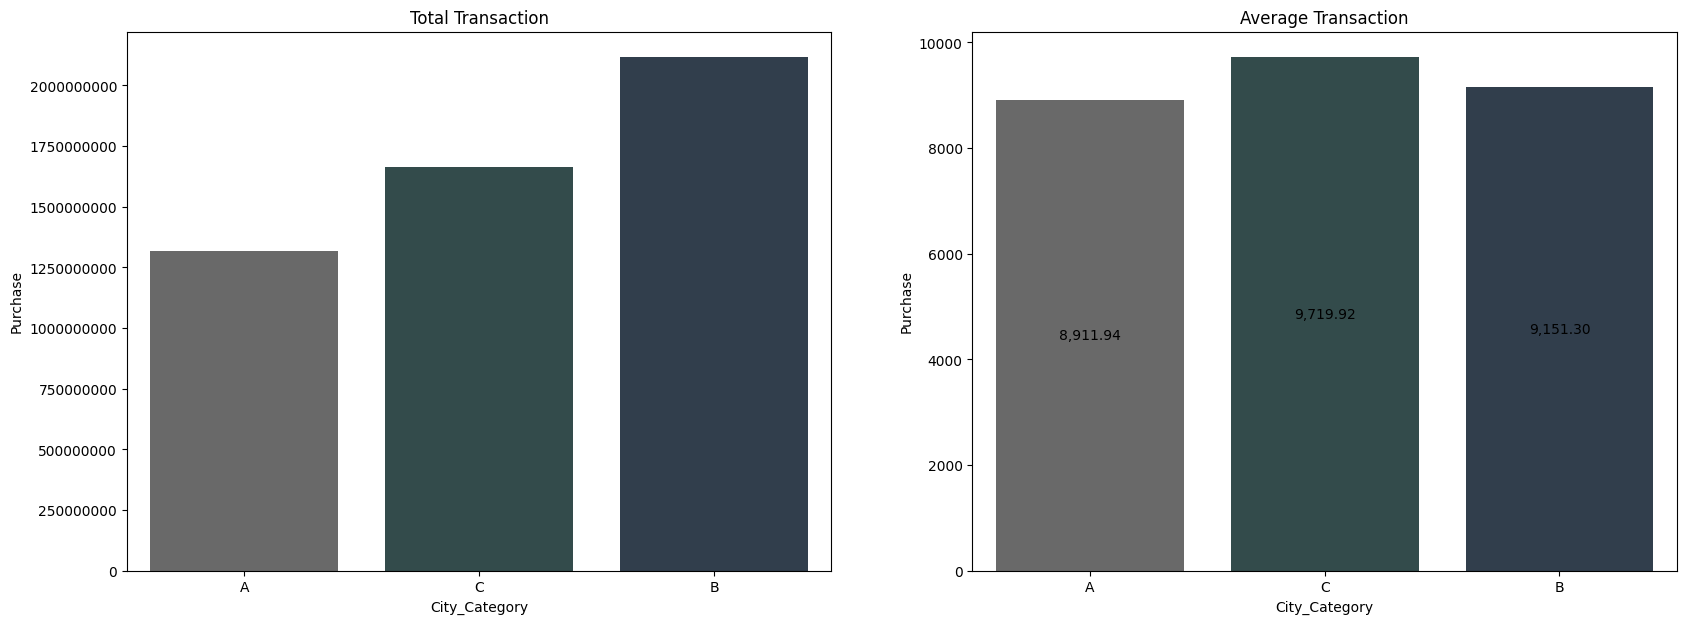

In [46]:
colors = ['dimgray','darkslategray','#2c3e50']
fig, ax =plt.subplots(1,2,figsize=(20,7))
sns.barplot(x = 'City_Category',y = 'Purchase', data = df,palette = colors,estimator= 'sum', ax = ax[0],errorbar = None)
ax[0].ticklabel_format(style = 'plain', axis = 'y')
ax[0].set_title('Total Transaction')

sns.barplot(x = 'City_Category',y = 'Purchase',data = df, palette = colors,ax = ax[1],errorbar = None)
ax[1].set_title('Average Transaction')
ax[1].ticklabel_format(style = 'plain', axis = 'y')
for container in ax[1].containers:
  ax[1].bar_label(container,fmt = '{:,.2f}', label_type = 'center')

plt.show()

▶ Customers belongs to city Category B, spends maximum.

▶ Clear difference in average per transaction, as customer from city category C has highest average per transaction, this is the highest in comparison to the maximum average per transaction of any demography.

* Since, Average per transaction of city category C is clealy above the rest,testing is there difference between average per transaction of city category A and B.

In [47]:
city_A = df[df['City_Category']=='A']
city_B = df[df['City_Category']=='B']

In [48]:
# testing average per transaction of city B is greater than A or not
hypothesis_testing(city_B,city_A,[10000,20000,30000],"Not greater","greater",95,.05,['B','A'])

sample Size: 10000, Confidence level: 95%
P-value2.4776498341047906e-07 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of B is greater than A.


sample Size: 20000, Confidence level: 95%
P-value2.4843907849499716e-08 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of B is greater than A.


sample Size: 30000, Confidence level: 95%
P-value1.2121165590010288e-09 < 0.05 thus, we reject the null hypothesis.
Average Per Transaction of B is greater than A.




▶ Average per transaction of each city category is different from each other, where C>B>A.

# Question related to city category.

Q.1 segment of city category C and Male has highest average per transaction, check the relation of city category with Age to find some important segments.

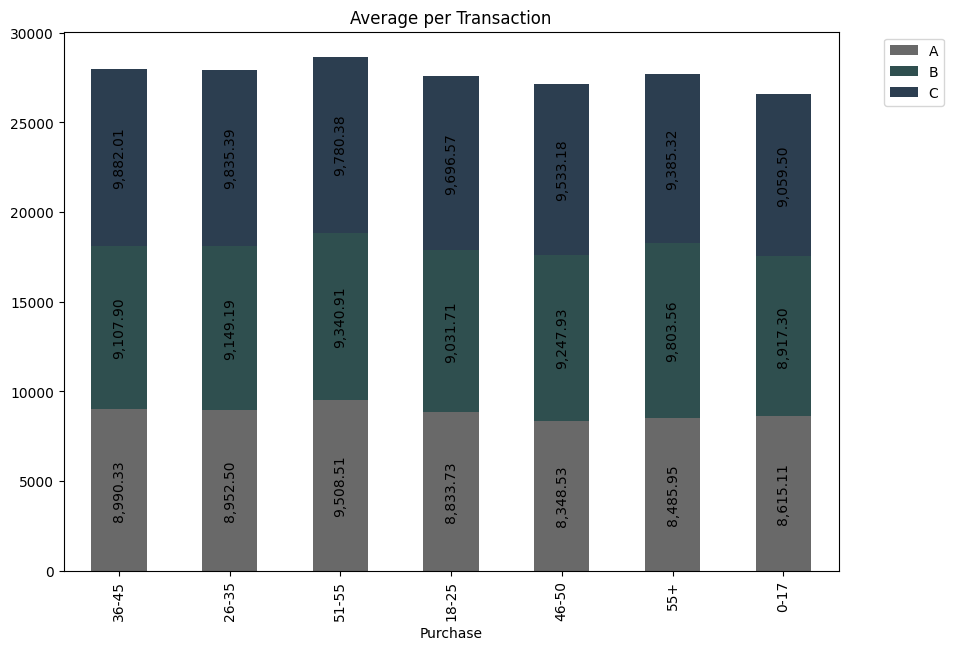

In [49]:
city_age = df.groupby(['Age', 'City_Category'])['Purchase'].mean().unstack().sort_values(by = ['C','B'], ascending = False)
fig,ax = plt.subplots(1,1, figsize = (10,7))
city_age.plot(kind = 'bar', stacked = 'True', color = colors, ax = ax)
ax.set_xlabel('Purchase')
ax.set_title('Average per Transaction')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for i in ax.containers:
  ax.bar_label(i, fmt = '{:,.2f}', label_type = 'center',rotation = 90)
plt.show()

▶ This relation is interesting where both the columns has influence over each other.

▶ Customer from each age group living in city category C has high average per transaction compare to there average per transaction without any filter.similarly, customer living in any city between 51-55 age has high average per transaction after applying this filter.

▶ This relation has disclosed various important segment, important for customer acquision.

# Stay in the current city years column.

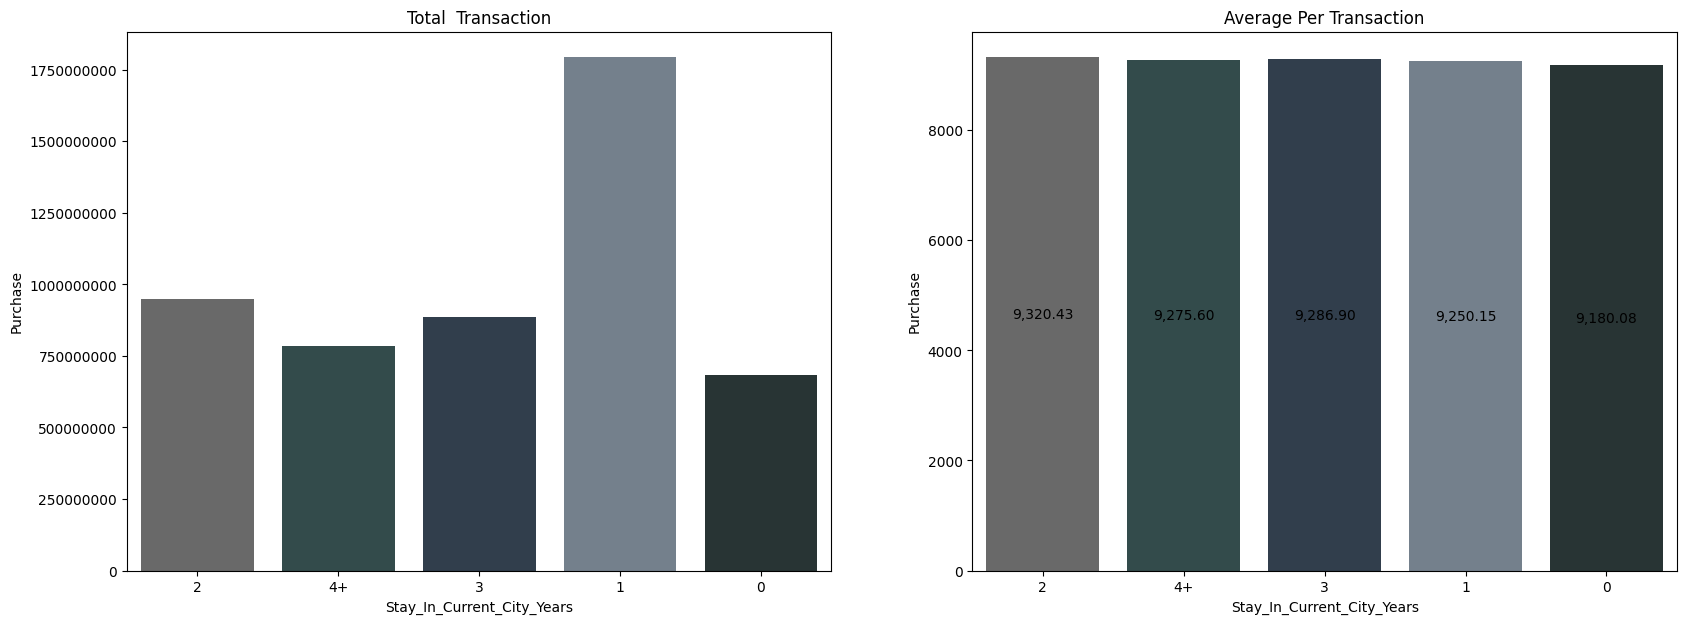

In [50]:
c = ['dimgray','darkslategray','#2c3e50','slategray','#263636']
fig, ax =plt.subplots(1,2,figsize=(20,7))
sns.barplot(x = 'Stay_In_Current_City_Years',y = 'Purchase', data = df,palette = c,estimator= 'sum', ax = ax[0],errorbar = None)
ax[0].ticklabel_format(style = 'plain', axis = 'y')
ax[0].set_title('Total  Transaction')

sns.barplot(x = 'Stay_In_Current_City_Years',y = 'Purchase',data = df, palette = c,ax = ax[1],errorbar = None)
ax[1].set_title('Average Per Transaction')
ax[1].ticklabel_format(style = 'plain', axis = 'y')
for container in ax[1].containers:
  ax[1].bar_label(container,fmt = '{:,.2f}', label_type = 'center')

plt.show()

▶ No clear difference in average per transaction.

▶ people living from 1 year spends the most, but after that it is gradually decreasing which is a matter of concern.


# Question Stay in the current city years

Q.1 With number of years in the city increases total transaction gradually decreases, check is this pattern is similar in all the city category.


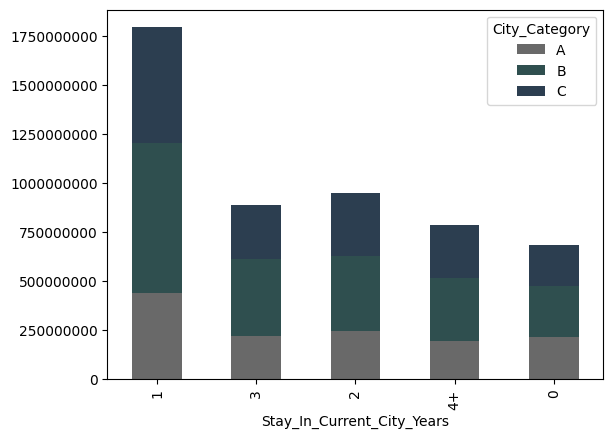

In [55]:
grp_data = df.groupby(['Stay_In_Current_City_Years','City_Category'])['Purchase'].sum().unstack().sort_values(by =['B','C'], ascending =  False)
grp_data.plot(kind = 'bar', stacked = True, color = colors)
plt.ticklabel_format(style ='plain', axis = 'y')
plt.show()

▶ The gradual decrease in total transaction can be observed in all the city category with increase in years.

# Product Category column

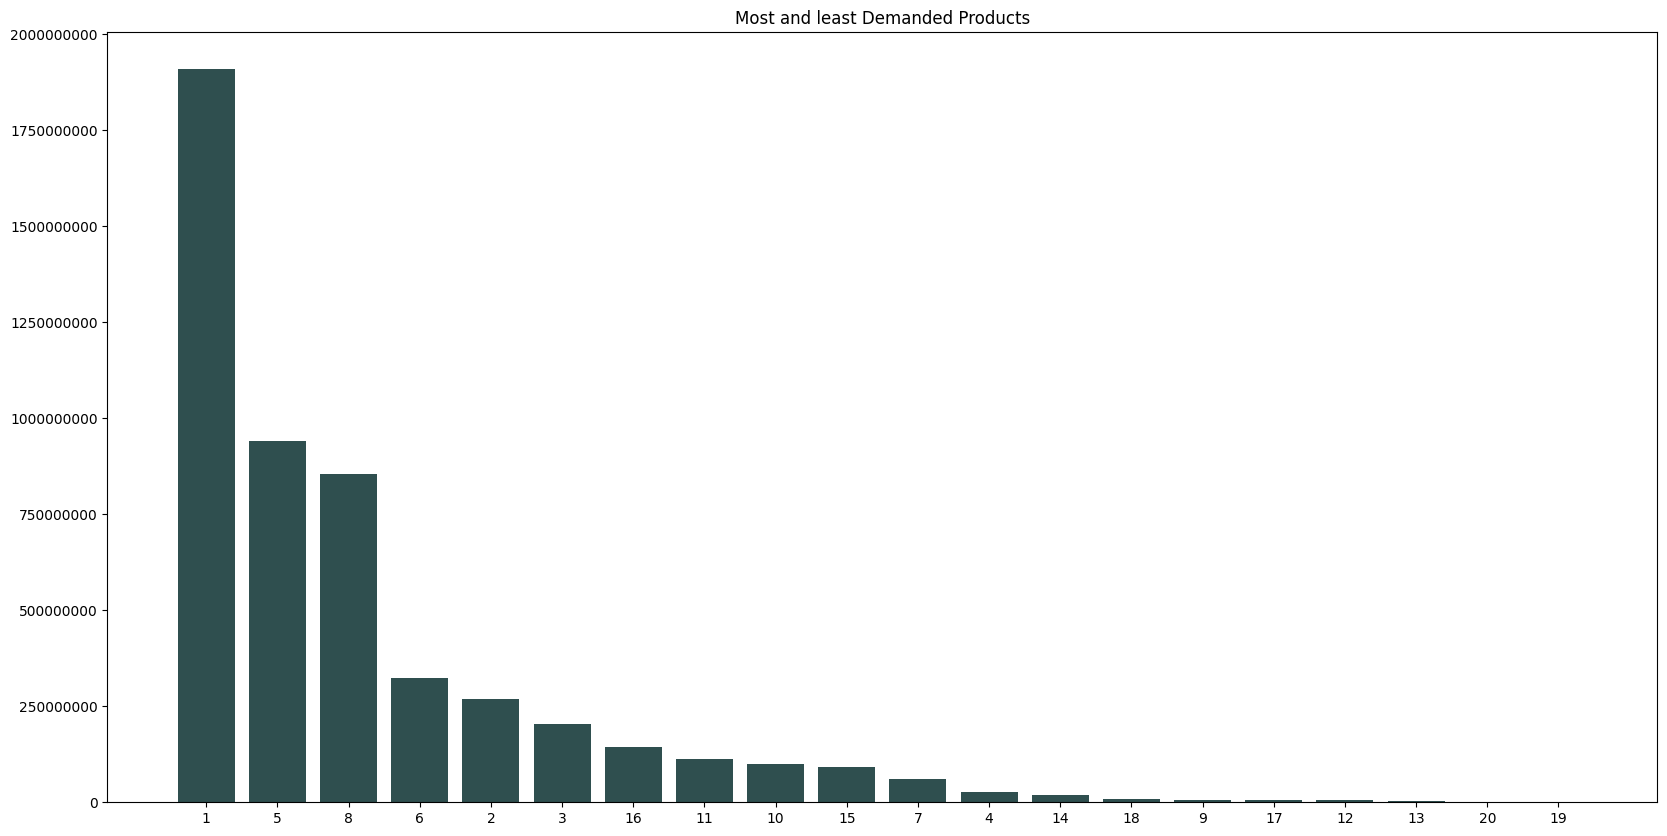

In [51]:
# Most demanded and least demanded products
plt.figure(figsize = (20,10))
dta= df.groupby('Product_Category')['Purchase'].sum().sort_values(ascending = False)
plt.bar(dta.index.astype(str),dta,color ='darkslategray')
plt.title('Most and least Demanded Products')
plt.ticklabel_format(style = 'plain', axis = 'y')

plt.show()


▶ product category 1 is most demanded category, but the difference between 1 and others is huge.

# Question related to product Category.
Q.1 Check average per transaction. compare them with least demanded products to confirn,does expensive products are less demanded products.

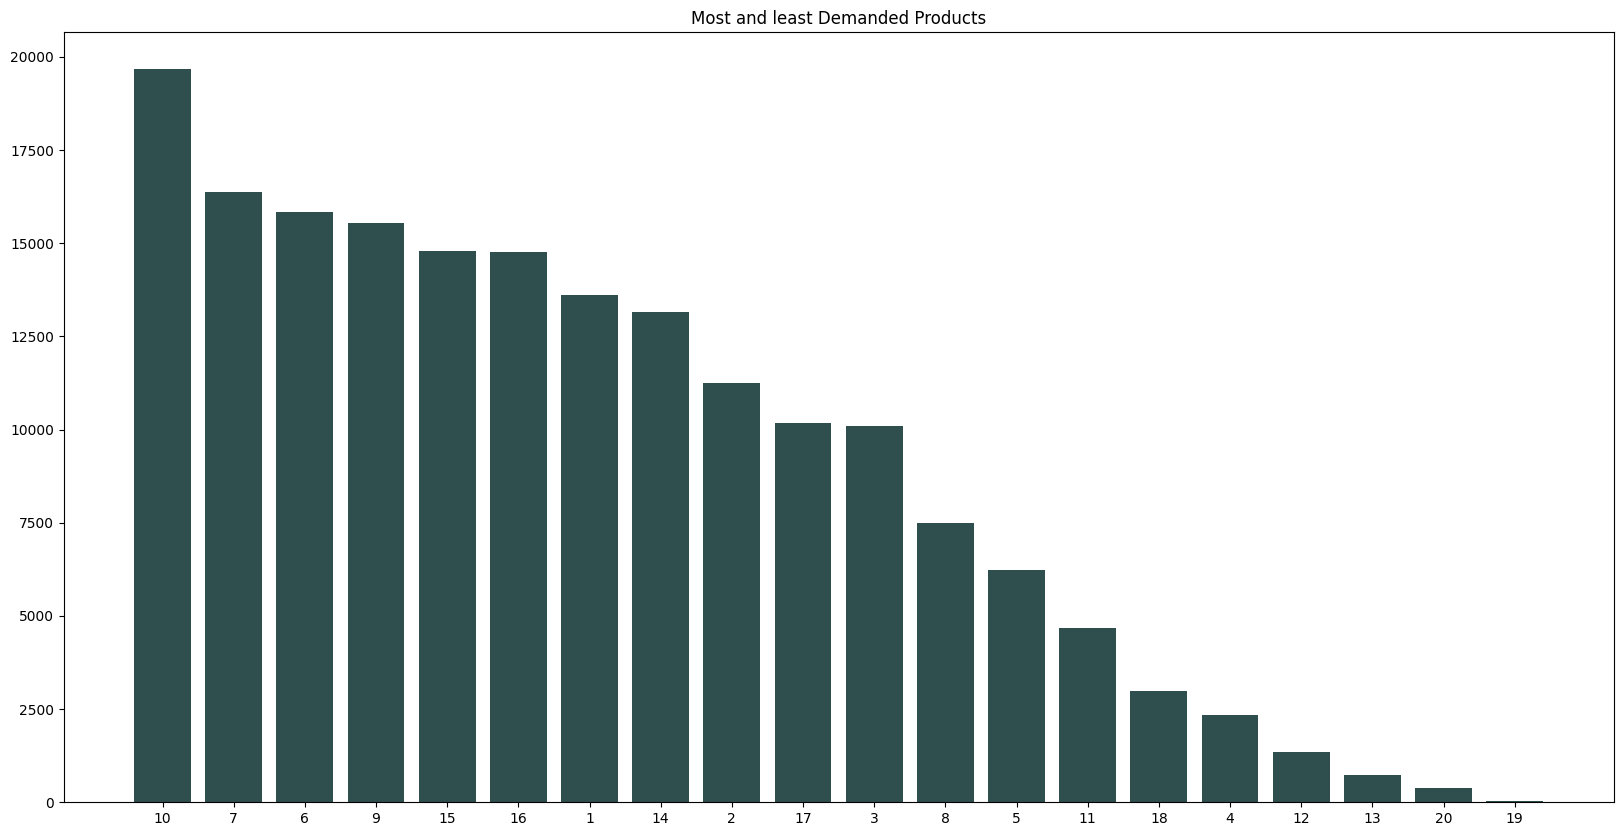

In [52]:
plt.figure(figsize = (20,10))
dta= df.groupby('Product_Category')['Purchase'].mean().sort_values(ascending = False)
plt.bar(dta.index.astype(str),dta,color ='darkslategray')
plt.title('Most and least Demanded Products')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()


▶ Expensive products are neither high demanded nor low demanded.

▶ Cheap products are least demanded products.

▶ Mid range products are high demanded products.

# Highest spending users

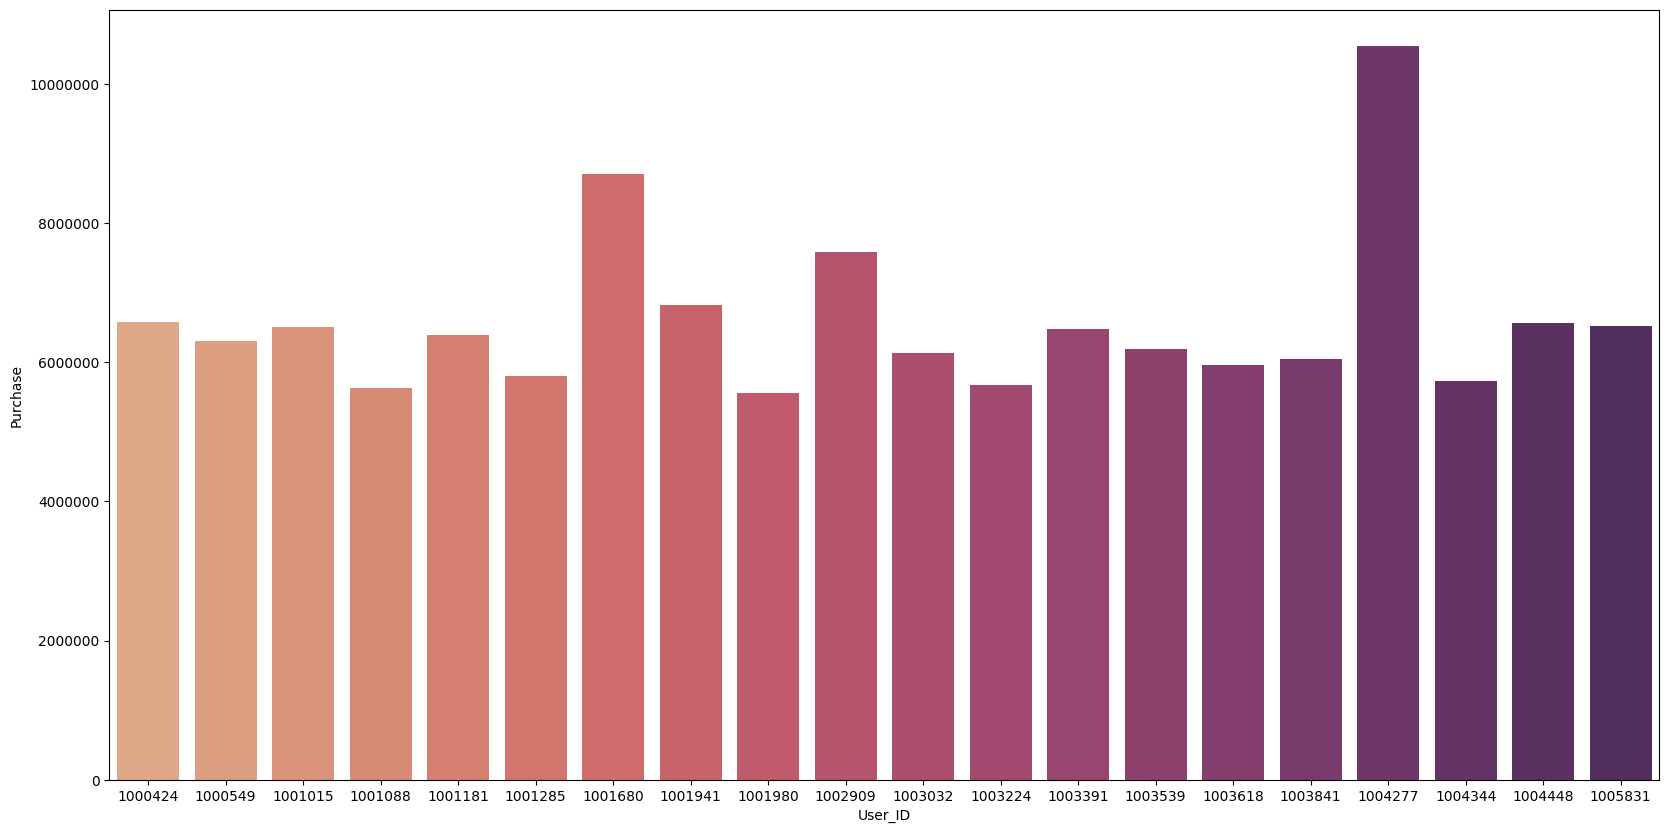

In [ ]:
plt.figure(figsize = (20,10))
top_users = df.groupby('User_ID')['Purchase'].sum().reset_index().nlargest(n=20, columns='Purchase')
sns.barplot(x = 'User_ID', y ='Purchase', data = top_users, palette = 'flare')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

**Note:** This data is collected from single day of transaction(Black Friday) so,columns like user id will not as useful insights as demography.

# Insights

1. Purchasing pattern is same irrespective of demography.
2. Gender with 70% male influencing other columns.
3. customer participation is main reason behind revenue generation.
4. Marital Status has no impact.
5. customer's spending in walmart store is gradually decreasing with increase in years the have lived in the city.
7. products from categoru 1,5,8 are most demanded while 12,1317,18,19,20 are least demanded.
8. Customer retention is a serious issue.

# Reccomendations
1. segement (male,51-55),(male,C),(C,18-55), focus on acquiring customers from this segment.
2. Keep abundent stock of product category 1,5,8.
3. Customer retention is gradually suffering,moniter internal factors like quality check and external factors like competition to understand the potential reason.